In [1]:
import time
%matplotlib widget

from scipy.constants import hbar, m_e, eV, physical_constants
## necessary modules
import numpy as np
from tqdm import tqdm
from matplotlib.patches import ConnectionPatch
import random
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy import integrate
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from pfapack.ctypes import pfaffian as cpf
from scipy import sparse
from scipy.linalg import ishermitian
from OneD_nanowire_utils import construct_Hamil, Diagonalize, Energy_spectrum, wavefunc, Energy_spectrum_phi, Energy_spectrum_v_VQD, pfaffian_calculation, Energy_tracker_phi, Energy_tracker_VQD, Topological_stability, Gen_disorder, Energy_GS_curvature_phi
from transport_quantities_1D_nanowire import capacitance, Capacitance_vs_phi, Capacitance_vs_VQD, inductance, inductance_vs_phi, inductance_vs_VQD
from config_1D_nanowire import ModelParams
import matplotlib.ticker as ticker
from joblib import Parallel, delayed
from copy import deepcopy

## define the pauli matrices
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]]) 

In [11]:
V0 = 0.3
N = 300
disorder_file = "Disorder_N_300_Broy.txt"
V_dis = V0*np.array(np.loadtxt(open(disorder_file, "rb"), skiprows=0))
S = np.array([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]])
params = ModelParams(Disorder=V_dis[:N], chirality_op=S)
params.Length = N
print(np.sqrt(np.mean(V_dis**2.0)))

0.30000000000000004


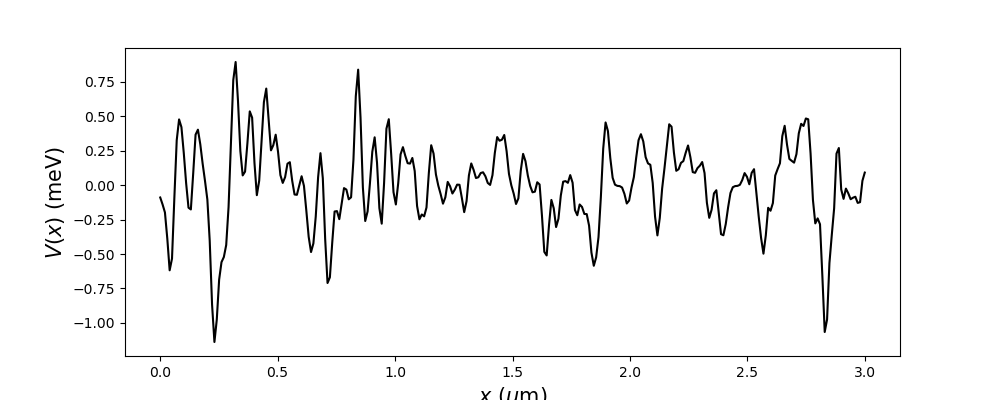

In [3]:
sigma = 50# was 70 previously
x0 = 0.0
x1 = params.Length
def Potential(x, V_0):
    return V_0*(
        np.exp(-((int(x/2) - x0) ** 2) / (2 * sigma**2))
        + np.exp(-((x1 - int(x/2)) ** 2) / (2 * sigma**2))
    )

x = np.linspace(0.0,3.0,params.Length)
pot_V = []
for i in range(0,2*params.Length,2):
    pot_V.append(Potential(i, V0))
pot_V = np.array(pot_V)
#V_dis = pot_V
params = ModelParams(Disorder=V_dis[:N])
params.Length = N
fig, ax_v = plt.subplots(figsize=(10, 4))
ax_v.plot(x, params.Disorder, label=r"$V(x)$", color="black")
ax_v.set_xlabel(r"$x$ ($\mu$m)", fontsize=15)
ax_v.set_ylabel(r"$V(x)$ (meV)", fontsize=15)
plt.show()

In [13]:
##Local Parameters##
mu_loc = 0.5
Ez_loc = 0.8
V_QD_low_loc = mu_loc - 0.1
V_QD_high_loc = mu_loc + 0.2
V_QD_points_loc = 400
phi_low_loc = 0.0
phi_high_loc = 2.0*np.pi
phi_points_loc = 400
gam_low_loc = 0.25
gam_high_loc = 1.25
gam_points_loc = 400
w_left_loc = 0.025
w_right_loc = 0.025
V_QD_loc = mu_loc + 0.045
No_QD_loc = False
params = ModelParams(
    mu=mu_loc, 
    Ez=Ez_loc, 
    w_left=w_left_loc, 
    w_right=w_right_loc, 
    V_QD_low=V_QD_low_loc, 
    V_QD_high=V_QD_high_loc, 
    V_QD_points=V_QD_points_loc, 
    Ez_low=gam_low_loc, 
    Ez_high=gam_high_loc, 
    Ez_points=gam_points_loc,
    phi_low=phi_low_loc,
    phi_high=phi_high_loc,
    phi_points=phi_points_loc, 
    V_QD=V_QD_loc,
    Disorder=V_dis[:N], 
    chirality_op=S,
                     )
params.Length = N
gam_range_loc = np.linspace(gam_low_loc, gam_high_loc, gam_points_loc)
vqd_range_loc = np.linspace(V_QD_low_loc, V_QD_high_loc, V_QD_points_loc)
phi_range_loc = np.linspace(phi_low_loc, phi_high_loc, phi_points_loc)

In [16]:
C_vs_vqd_0, C_vs_vqd_pi = np.zeros((2,400)), np.zeros((2,400))
L_vs_vqd_P_0, L_vs_vqd_D_0, L_vs_vqd_P_pi, L_vs_vqd_D_pi = np.zeros((2,400)), np.zeros((2,400)), np.zeros((2,400)), np.zeros((2,400))
p_av = deepcopy(params)
mu_loc = 0.5
Ez_loc = 0.8
p_av.V_QD_high = 0.7
p_av.V_QD_low = 0.4
p_av.w_left = 0.025
p_av.w_right = 0.025
C_vs_vqd_0[0], C_vs_vqd_pi[0] = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=100, n_jobs=-1)
L_vs_vqd_P_0[0], L_vs_vqd_D_0[0], L_vs_vqd_P_pi[0], L_vs_vqd_D_pi[0] = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=100, n_jobs=-1)
p_av = deepcopy(params)
mu_loc = 0.5
Ez_loc = 0.4
p_av.V_QD_high = 0.7
p_av.V_QD_low = 0.4
p_av.w_left = 0.025
p_av.w_right = 0.025
C_vs_vqd_0[1], C_vs_vqd_pi[1] = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=100, n_jobs=-1)
L_vs_vqd_P_0[1], L_vs_vqd_D_0[1], L_vs_vqd_P_pi[1], L_vs_vqd_D_pi[1] = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=100, n_jobs=-1)

  8%|▊         | 32/400 [00:02<00:30, 11.93it/s]

KeyboardInterrupt: 

In [22]:
Ez_loc = 0.6
params.V_QD = 0.545
#mf_wf1_tp, mf_wf2_tp, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=True, params=params)
#C_vs_phi_even_1, C_vs_phi_odd_1 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=100)
#L_vs_phi_even_P_1, L_vs_phi_even_D_1, L_vs_phi_odd_P_1, L_vs_phi_odd_D_1 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=100)
Ez_loc = 0.3
params.V_QD = 0.525
mf_wf1_tr, mf_wf2_tr, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=True, params=params)
C_vs_phi_even_2, C_vs_phi_odd_2 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=100)
L_vs_phi_even_P_2, L_vs_phi_even_D_2, L_vs_phi_odd_P_2, L_vs_phi_odd_D_2 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=100)

100%|██████████| 400/400 [00:12<00:00, 30.87it/s]


/var/folders/48/y24539z12pz_600tsnssd6vr0000gn/T/ipykernel_48977/4285301209.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


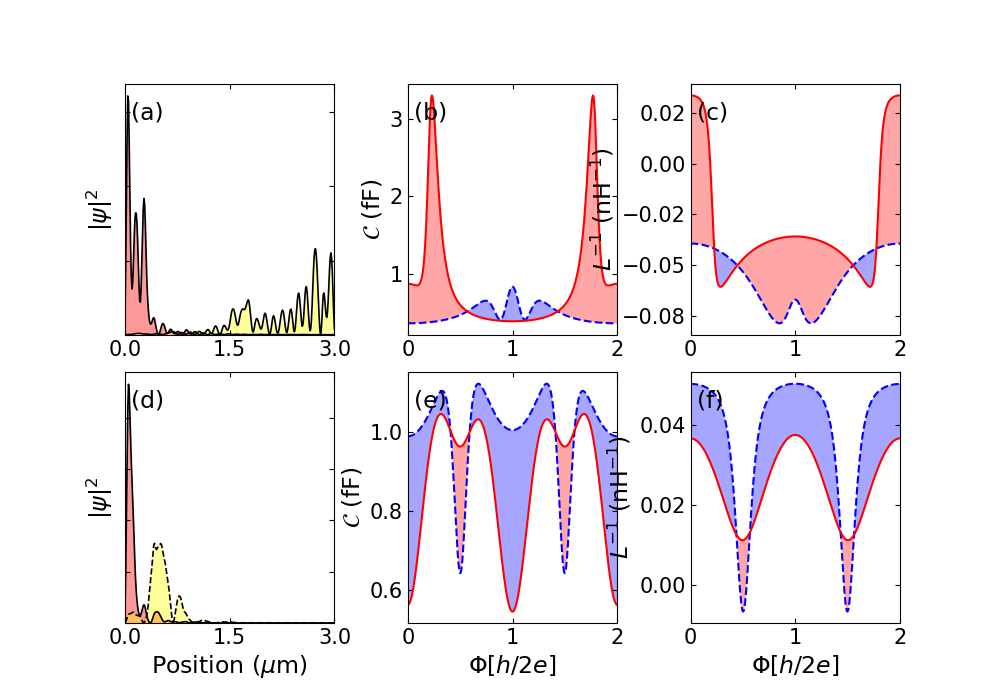

In [23]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mtick

fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 3, figure=fig, hspace=0.15, wspace=0.35)

angles = np.linspace(0.0, 2.0, phi_points_loc)
wire   = np.linspace(0.0, 3.0, 300)  # last point is the QD
qd_x   = wire[-1]

# ------------------------------------------------------------------
# Top row: TOPOLOGICAL REGIME
# ------------------------------------------------------------------
ax_wf1 = fig.add_subplot(gs[0, 0])
ax_C1  = fig.add_subplot(gs[0, 1])
ax_L1  = fig.add_subplot(gs[0, 2])

# ---- wavefunction with filled lobes ----
# fill first so lines stay visible on top
ax_wf1.fill_between(wire, 0.0, mf_wf1_tp,
                    where=mf_wf1_tp >= 0,
                    facecolor='red', alpha=0.4, step='mid')
ax_wf1.fill_between(wire, 0.0, mf_wf2_tp,
                    where=mf_wf2_tp >= 0,
                    facecolor='yellow', alpha=0.4, step='mid')

ax_wf1.plot(wire, mf_wf1_tp, color='k', lw=1.2)
ax_wf1.plot(wire, mf_wf2_tp, color='k', lw=1.2)

ax_wf1.set_ylabel(r'$|\psi|^2$', fontsize=17)
ax_wf1.set_xlim(wire[0], wire[-1])
ax_wf1.set_ylim(0.0, None)
ax_wf1.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_wf1.xaxis.set_major_locator(ticker.FixedLocator([0.0,1.5,3.0]))
ax_wf1.set_yticklabels([])

# ---- capacitance with shaded regions between even/odd ----
mask_C1 = C_vs_phi_even_1 >= C_vs_phi_odd_1

ax_C1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1,
                   where=mask_C1,
                   facecolor='blue', alpha=0.35)
ax_C1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1,
                   where=~mask_C1,
                   facecolor='red', alpha=0.35)

ax_C1.plot(angles, C_vs_phi_even_1, color='b', lw=1.5, ls='--', label='Even parity')
ax_C1.plot(angles, C_vs_phi_odd_1,  color='r', lw=1.5,          label='Odd parity')

ax_C1.set_ylabel(r'$\mathcal{C}$ (fF)', fontsize=17)
ax_C1.set_xlim(0.0, 2.0)
ax_C1.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_C1.xaxis.set_major_locator(ticker.FixedLocator([0.0,1.0,2.0]))

# ---- L^{-1} with shaded regions between even/odd ----
L_vs_phi_even_1 = L_vs_phi_even_D_1 + L_vs_phi_even_P_1
L_vs_phi_odd_1  = L_vs_phi_odd_D_1  + L_vs_phi_odd_P_1
mask_L1 = L_vs_phi_even_1 >= L_vs_phi_odd_1

ax_L1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1,
                   where=mask_L1,
                   facecolor='blue', alpha=0.35)
ax_L1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1,
                   where=~mask_L1,
                   facecolor='red', alpha=0.35)

ax_L1.plot(angles, L_vs_phi_even_1, color='b', lw=1.5, ls='--', label='Even parity')
ax_L1.plot(angles, L_vs_phi_odd_1,  color='r', lw=1.5,          label='Odd parity')

ax_L1.set_ylabel(r'$L^{-1}$ (n$\mathrm{H}^{-1}$)', fontsize=17)
ax_L1.set_xlim(0.0, 2.0)
ax_L1.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_L1.xaxis.set_major_locator(ticker.FixedLocator([0.0,1.0,2.0]))
ax_L1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.2f}'))

# ------------------------------------------------------------------
# Bottom row: TRIVIAL REGIME
# ------------------------------------------------------------------
ax_wf2 = fig.add_subplot(gs[1, 0], sharex=ax_wf1)
ax_C2  = fig.add_subplot(gs[1, 1], sharex=ax_C1)
ax_L2  = fig.add_subplot(gs[1, 2], sharex=ax_L1)

# wavefunction with fill_between
ax_wf2.fill_between(wire, 0.0, mf_wf1_tr,
                    where=mf_wf1_tr >= 0,
                    facecolor='red', alpha=0.4, step='mid')
ax_wf2.fill_between(wire, 0.0, mf_wf2_tr,
                    where=mf_wf2_tr >= 0,
                    facecolor='yellow', alpha=0.4, step='mid')

ax_wf2.plot(wire, mf_wf1_tr, color='k', lw=1.2, label='ground state')
ax_wf2.plot(wire, mf_wf2_tr, color='k', lw=1.2, ls='--', label='excited state')

ax_wf2.set_xlabel(r'Position ($\mu$m)', fontsize=17)
ax_wf2.set_ylabel(r'$|\psi|^2$', fontsize=17)
ax_wf2.set_xlim(wire[0], wire[-1])
ax_wf2.tick_params(labelsize=15, direction='in', top=True, right=True)
ax_wf2.set_yticklabels([])
ax_wf2.set_ylim(0.0, None)

# capacitance shading
mask_C2 = C_vs_phi_even_2 >= C_vs_phi_odd_2
ax_C2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2,
                   where=mask_C2,
                   facecolor='blue', alpha=0.35)
ax_C2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2,
                   where=~mask_C2,
                   facecolor='red', alpha=0.35)

ax_C2.plot(angles, C_vs_phi_even_2, color='b', lw=1.5, ls='--', label='Even parity')
ax_C2.plot(angles, C_vs_phi_odd_2,  color='r', lw=1.5,          label='Odd parity')

ax_C2.set_xlabel(r'$\Phi[h/2e]$', fontsize=17)
ax_C2.set_ylabel(r'$\mathcal{C}$ (fF)', fontsize=17)
ax_C2.set_xlim(0.0, 2.0)
ax_C2.tick_params(labelsize=15, direction='in', top=True, right=True)

# L^{-1} shading
L_vs_phi_even_2 = L_vs_phi_even_D_2 + L_vs_phi_even_P_2
L_vs_phi_odd_2  = L_vs_phi_odd_D_2  + L_vs_phi_odd_P_2
mask_L2 = L_vs_phi_even_2 >= L_vs_phi_odd_2

ax_L2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2,
                   where=mask_L2,
                   facecolor='blue', alpha=0.35)
ax_L2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2,
                   where=~mask_L2,
                   facecolor='red', alpha=0.35)

ax_L2.plot(angles, L_vs_phi_even_2, color='b', lw=1.5, ls='--', label='Even parity')
ax_L2.plot(angles, L_vs_phi_odd_2,  color='r', lw=1.5,          label='Odd parity')

ax_L2.set_xlabel(r'$\Phi[h/2e]$', fontsize=17)
ax_L2.set_ylabel(r'$L^{-1}$ (n$\mathrm{H}^{-1}$)', fontsize=17)
ax_L2.set_xlim(0.0, 2.0)
ax_L2.tick_params(labelsize=15, direction='in', top=True, right=True)

# ------------------------------------------------------------------
# Panel labels (a)–(f) inside boxes
# ------------------------------------------------------------------
axes = [ax_wf1, ax_C1, ax_L1, ax_wf2, ax_C2, ax_L2]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, lab in zip(axes, labels):
    ax.text(0.03, 0.93, lab,
            transform=ax.transAxes,
            fontsize=17,
            va='top', ha='left')

plt.tight_layout()

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_V0_03_sys_benchmark_Tp_Tr_regime_alt.pdf")
plt.show()


/var/folders/48/y24539z12pz_600tsnssd6vr0000gn/T/ipykernel_7751/3458932583.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


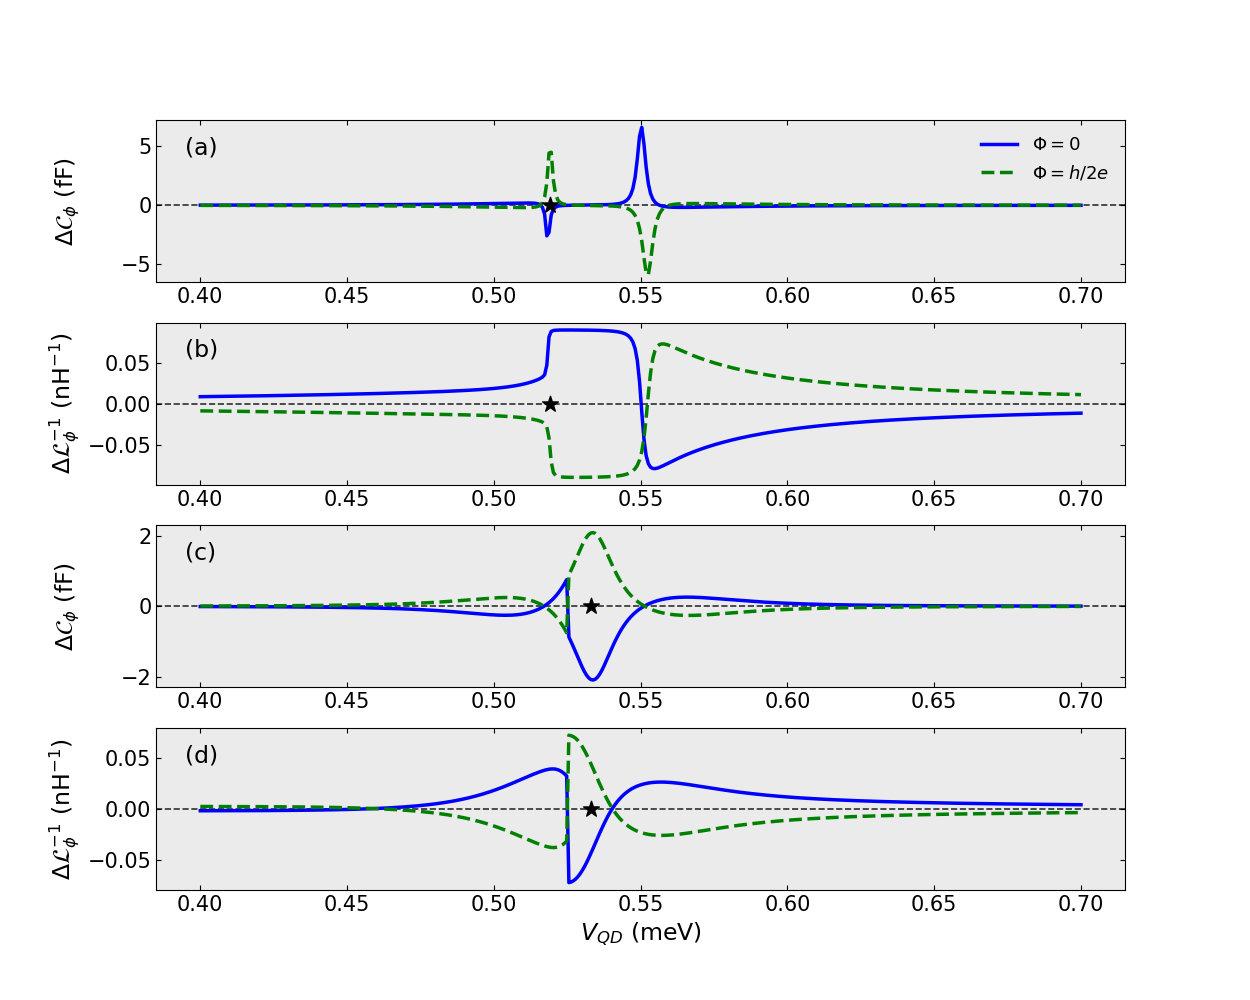

In [8]:
vqd_r1 = np.linspace(1.2,1.6,400)
vqd_r1 = np.linspace(1.1,1.5,400)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# professional colors (keep consistent with your previous figure)
blue_col  = "blue"
green_col = "green"

lw = 2.5  # you can set to 2 if you want consistency with other figures

# ---- You must set these two windows (one per parameter set) ----
# Each tuple is (VQD_min, VQD_max) for that parameter set
VQD_ranges = [
    (0.4, 0.7),
    (0.4, 0.7),
]

# ---- Star positions: one per parameter set (used for BOTH C and L panels in that set) ----
VQD_star = [0.519, 0.533]

# Build VQD arrays (length inferred from data)
VQD_arrays = [
    np.linspace(VQD_ranges[j][0], VQD_ranges[j][1], C_vs_vqd_0.shape[1])
    for j in range(2)
]

# Precompute L curves
L_vs_vqd_0  = L_vs_vqd_P_0  + L_vs_vqd_D_0
L_vs_vqd_pi = L_vs_vqd_P_pi + L_vs_vqd_D_pi

fig = plt.figure(figsize=(12.5, 10.0))
gs = GridSpec(4, 1, figure=fig, hspace=0.25)
axes = [fig.add_subplot(gs[i, 0]) for i in range(4)]

panel_labels = ['(a)', '(b)', '(c)', '(d)']

# Helper to style axes consistently
def style_axis(ax, label_text):
    ax.set_facecolor("0.92")
    ax.axhline(0.0, color="k", lw=1.2, ls="--", alpha=0.8)
    ax.tick_params(labelsize=15, direction="in", top=True, right=True)
    ax.text(0.03, 0.90, label_text,
            transform=ax.transAxes,
            fontsize=17, va="top", ha="left")

# ---- Panel (a): ΔC, set 0 ----
j = 0
ax = axes[0]
style_axis(ax, panel_labels[0])
ax.plot(VQD_arrays[j], C_vs_vqd_0[j],  color=blue_col,  lw=lw, label=r"$\Phi=0$")
ax.plot(VQD_arrays[j], C_vs_vqd_pi[j], color=green_col, lw=lw, ls="--", label=r"$\Phi=h/2e$")
ax.scatter(VQD_star[j], 0.0, marker='*', s=140, color='k', zorder=6)
ax.set_ylabel(r"$\Delta \mathcal{C}_\phi$ (fF)", fontsize=17)
ax.legend(fontsize=13, frameon=False, loc="upper right")

# ---- Panel (b): ΔL^{-1}, set 0 ----
ax = axes[1]
style_axis(ax, panel_labels[1])
ax.plot(VQD_arrays[j], L_vs_vqd_0[j],  color=blue_col,  lw=lw, label=r"$\Phi=0$")
ax.plot(VQD_arrays[j], L_vs_vqd_pi[j], color=green_col, lw=lw, ls="--", label=r"$\Phi=h/2e$")
ax.scatter(VQD_star[j], 0.0, marker='*', s=140, color='k', zorder=6)
ax.set_ylabel(r"$\Delta \mathcal{L}^{-1}_\phi$ (nH$^{-1}$)", fontsize=17)

# ---- Panel (c): ΔC, set 1 ----
j = 1
ax = axes[2]
style_axis(ax, panel_labels[2])
ax.plot(VQD_arrays[j], C_vs_vqd_0[j],  color=blue_col,  lw=lw, label=r"$\Phi=0$")
ax.plot(VQD_arrays[j], C_vs_vqd_pi[j], color=green_col, lw=lw, ls="--", label=r"$\Phi=h/2e$")
ax.scatter(VQD_star[j], 0.0, marker='*', s=140, color='k', zorder=6)
ax.set_ylabel(r"$\Delta \mathcal{C}_\phi$ (fF)", fontsize=17)

# ---- Panel (d): ΔL^{-1}, set 1 ----
ax = axes[3]
style_axis(ax, panel_labels[3])
ax.plot(VQD_arrays[j], L_vs_vqd_0[j],  color=blue_col,  lw=lw, label=r"$\Phi=0$")
ax.plot(VQD_arrays[j], L_vs_vqd_pi[j], color=green_col, lw=lw, ls="--", label=r"$\Phi=h/2e$")
ax.scatter(VQD_star[j], 0.0, marker='*', s=140, color='k', zorder=6)
ax.set_ylabel(r"$\Delta \mathcal{L}^{-1}_\phi$ (nH$^{-1}$)", fontsize=17)

# X label only on bottom panel
axes[-1].set_xlabel(r"$V_{QD}$ (meV)", fontsize=17)

# Force y-label alignment
fig.align_ylabels(axes)

plt.tight_layout()
#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_w_004_sys_transport_delta_transport.pdf")
plt.show()


In [49]:
mu_loc = 0.5
p_av = deepcopy(params)
p_av.eta = 0
p_av.V_QD = 0.519
Ez_loc = 0.65
L_vs_phi_even_P_1, L_vs_phi_even_D_1, L_vs_phi_odd_P_1, L_vs_phi_odd_D_1 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=100)
L_vs_phi_even_1 = L_vs_phi_even_P_1 + L_vs_phi_even_D_1
L_vs_phi_odd_1 = L_vs_phi_odd_P_1 + L_vs_phi_odd_D_1
#C_vs_phi_even_1, C_vs_phi_odd_1 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=40)
_, Even_1, Odd_1 = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, num_eigvals=100)
_, ind11 = Energy_GS_curvature_phi(Even_1, p_av)
_, ind12 = Energy_GS_curvature_phi(Odd_1, p_av)
p_av = deepcopy(params)
p_av.eta = 0
Ez_loc = 0.4
p_av.V_QD = 0.533
L_vs_phi_even_P_2, L_vs_phi_even_D_2, L_vs_phi_odd_P_2, L_vs_phi_odd_D_2 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=100)
L_vs_phi_even_2 = L_vs_phi_even_P_2 + L_vs_phi_even_D_2
L_vs_phi_odd_2 = L_vs_phi_odd_P_2 + L_vs_phi_odd_D_2
#C_vs_phi_even_2, C_vs_phi_odd_2 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=40)
_, Even_2, Odd_2 = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, num_eigvals=100)
_, ind21 = Energy_GS_curvature_phi(Even_2, p_av)
_, ind22 = Energy_GS_curvature_phi(Odd_2, p_av)

100%|██████████| 400/400 [00:05<00:00, 72.03it/s]


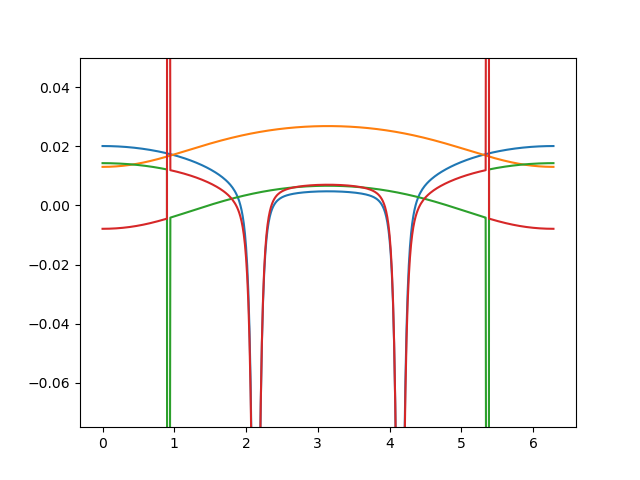

In [50]:
fig, ax = plt.subplots()
ax.plot(phi_range_loc, L_vs_phi_even_1/(1.48))
ax.plot(phi_range_loc, L_vs_phi_odd_1/(1.48))
ax.plot(phi_range_loc, ind11)
ax.plot(phi_range_loc, ind12)
ax.set_ylim(-0.075,0.05,)
plt.show()

In [ ]:
p_av = deepcopy(params)
#p_av.V_QD = 1.345
#mu_loc = 1.30
#Ez_loc = 0.66
L_vs_phi_even_P_1, L_vs_phi_even_D_1, L_vs_phi_odd_P_1, L_vs_phi_odd_D_1 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=40)
L_vs_phi_even_1 = L_vs_phi_even_P_1 + L_vs_phi_even_D_1
L_vs_phi_odd_1 = L_vs_phi_odd_P_1 + L_vs_phi_odd_D_1
C_vs_phi_even_1, C_vs_phi_odd_1 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_av, number_of_states=40)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# phi axis
phi = np.linspace(0.0, 2.0, len(Ep_1))

# colors
blue_col = "blue"   # even
red_col  = "red"    # odd

lw = 2
fill_alpha = 0.3

fig = plt.figure(figsize=(12.0, 10.0))
gs = GridSpec(3, 2, figure=fig, hspace=0.12, wspace=0.18)

# Left column = "case 1"
axE1 = fig.add_subplot(gs[0, 0])
axC1 = fig.add_subplot(gs[1, 0], sharex=axE1)
axL1 = fig.add_subplot(gs[2, 0], sharex=axE1)

# Right column = "case 2"
axE2 = fig.add_subplot(gs[0, 1], sharex=axE1)
axC2 = fig.add_subplot(gs[1, 1], sharex=axE1)
axL2 = fig.add_subplot(gs[2, 1], sharex=axE1)

# panel labels
panel_axes   = [axE1, axE2, axC1, axC2, axL1, axL2]
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(panel_axes, panel_labels):
    ax.text(0.03, 0.92, lab,
            transform=ax.transAxes,
            fontsize=17,
            va='top', ha='left')
    ax.tick_params(labelsize=15, direction='in', top=True, right=True)

# ---------------------------
# Helper function for identical plotting style
# ---------------------------
def plot_pair(ax, y_even, y_odd, ylabel):
    mask = (y_odd >= y_even)

    ax.fill_between(phi, y_even, y_odd,
                    where=mask,
                    color=red_col, alpha=fill_alpha, linewidth=0)
    ax.fill_between(phi, y_even, y_odd,
                    where=~mask,
                    color=blue_col, alpha=fill_alpha, linewidth=0)

    ax.plot(phi, y_even, color=blue_col, lw=lw)
    ax.plot(phi, y_odd,  color=red_col,  lw=lw)

    ax.set_ylabel(ylabel, fontsize=17)

# ---------------------------
# Energy arrays in micro-eV (COPY ONLY; originals untouched)
# ---------------------------
Ep_1_u = 1000.0 * np.array(Ep_1, copy=True)
En_1_u = 1000.0 * np.array(En_1, copy=True)

Ep_2_u = 1000.0 * np.array(Ep_2, copy=True)
E_n2_u = 1000.0 * np.array(E_n2, copy=True)

# ---------------------------
# Left column (case 1)
# ---------------------------
plot_pair(axE1, Ep_1_u, En_1_u, r"Energy ($\mu$eV)")
plot_pair(axC1, C_vs_phi_even_1, C_vs_phi_odd_1, r"$\mathcal{C}$ (fF)")
plot_pair(axL1, L_vs_phi_even, L_vs_phi_odd,
          r"$\mathcal{L}^{-1}$ (nH$^{-1}$)")

# ---------------------------
# Right column (case 2)
# ---------------------------
plot_pair(axE2, Ep_2_u, E_n2_u, r"Energy ($\mu$eV)")
plot_pair(axC2, C_vs_phi_even_2, C_vs_phi_odd_2, r"$\mathcal{C}$ (fF)")
plot_pair(axL2, L_vs_phi_even_2, L_vs_phi_odd_2,
          r"$\mathcal{L}^{-1}$ (nH$^{-1}$)")

# ---------------------------
# X-axis formatting (bottom row only): ticks at 0.0,0.5,1.0,1.5,2.0
# ---------------------------
for ax in [axL1, axL2]:
    ax.set_xlabel(r"$\Phi\,[h/2e]$", fontsize=17)
    ax.set_xlim(0.0, 2.0)
    ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax.set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

# Hide x tick labels for top/middle rows (both columns)
for ax in [axE1, axE2, axC1, axC2]:
    ax.tick_params(labelbottom=False)

# ---------------------------
# Align all y-labels vertically
# ---------------------------
fig.align_ylabels([axE1, axC1, axL1, axE2, axC2, axL2])

for ax in [axE2, axC2, axL2]:
    ax.set_ylabel("")

plt.tight_layout()
#plt.savefig("../Impedance_calc_paper/Plots/Gaussian_dis_sys_transport_actual_and_double_c.pdf")
plt.show()


In [ ]:
def _worker_pf(Ez0, mu_loc, No_QD, params):
    return pfaffian_calculation(mu=mu_loc, Ez=Ez0, No_QD=No_QD, params=deepcopy(params))

def _worker_Ts(Ez0, mu_loc, No_QD, params, V_QD=None):
    p = deepcopy(params)
    if V_QD is not None:
        p.V_QD = V_QD
    return Topological_stability(mu=mu_loc, Ez=Ez0, No_QD=No_QD, params=p)

In [ ]:
mu_swp_ts = np.linspace(0.3, 0.8, 200)
Ts_1d = Parallel(n_jobs=-1, backend="loky")(
    delayed(_worker_Ts)(Ez_loc, mu_loc, False, params, V_QD=mu_loc + 0.051)
    for mu_loc in tqdm(mu_swp_ts)
)

In [ ]:
# -------------------- INPUT --------------------
mu = mu_swp_ts          # (200,)
Ts = np.array(Ts_1d)              # (200,), values in [-1, 1]

# -------------------- FIGURE --------------------
fig, ax = plt.subplots(figsize=(6.0, 3.5))

# Main line
ax.plot(mu, Ts, color="k", lw=2.0, zorder=3)

# Fill between Ts and zero
ax.fill_between(
    mu, Ts, 0.0,
    where=(Ts >= 0),
    interpolate=True,
    color="tab:red",
    alpha=0.35,
    label=r"$T_s > 0$"
)

ax.fill_between(
    mu, Ts, 0.0,
    where=(Ts <= 0),
    interpolate=True,
    color="tab:blue",
    alpha=0.35,
    label=r"$T_s < 0$"
)

# Zero reference line
ax.axhline(0.0, color="k", lw=1.2, ls="--", zorder=2)

# -------------------- AXES FORMATTING --------------------
ax.set_xlabel(r"$\mu$ (meV)", fontsize=14)
ax.set_ylabel(r"$T_s$", fontsize=14)

ax.set_ylim(-1.05, 1.05)
ax.set_xlim(mu.min(), mu.max())

ax.tick_params(direction="in", top=True, right=True, labelsize=12)

# Optional: remove legend if you want it ultra-minimal
# ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


In [ ]:
#Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=True, num_eigvals=100)#np.zeros((50,gam_points_loc))##
#pfaf_1d = Parallel(n_jobs=-1, backend="loky")(
#    delayed(_worker_pf)(Ez0, mu_loc, True, params)
#    for Ez0 in tqdm(gam_range_loc)
#)
#Ts_1d = Parallel(n_jobs=4, backend="loky")(
#    delayed(_worker_Ts)(Ez0, mu_loc, False, params)
#    for Ez0 in tqdm(gam_range_loc)
#)

c_params = deepcopy(params)
#c_params.V_QD = 0.545
#mf_wf1_tp, mf_wf2_tp, q_mf1, q_mf2, E_q_mzm = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=No_QD_loc, params=c_params)
#C_vs_phi_even_1, C_vs_phi_odd_1 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=40)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
#L_vs_phi_even_P_1, L_vs_phi_even_D_1, L_vs_phi_odd_P_1, L_vs_phi_odd_D_1 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
#Ep_1, En_1 = Energy_tracker_phi(mu=mu_loc, Ez=Ez_loc, params=c_params)

E_vs_vqd, _, _ = Energy_spectrum_v_VQD(mu=mu_loc, Ez=Ez_loc, phi=0.0, params=params)
E_vqd_p = deepcopy(params)
E_vqd_p.V_QD_points = 500
E_vqd_range = np.linspace(E_vqd_p.V_QD_low, E_vqd_p.V_QD_high, E_vqd_p.V_QD_points)
#Ep_0, En_0 = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, phi0=0.0, params=E_vqd_p)
#Ep_pi, En_pi = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, phi0=np.pi, params=E_vqd_p)
p_transport = deepcopy(params)
p_transport.V_QD_low=0.49
p_transport.V_QD_high=0.62
vqd_transport_range = np.linspace(p_transport.V_QD_low, p_transport.V_QD_high, p_transport.V_QD_points)
C_vs_vqd_0, C_vs_vqd_pi = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_transport, number_of_states=200)
#L_vs_vqd_P_0, L_vs_vqd_D_0, L_vs_vqd_P_pi, L_vs_vqd_D_pi = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_transport, number_of_states=200)

In [ ]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(3,1, figure=fig, height_ratios=[1, 1, 2], hspace=0.4)

label_size=15

ax_Espec = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra[0])):
        if (i != 49 and i != 50):
                ax_Espec.plot(gam_range_loc, Energy_spectra[:, i], "k", lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 49], color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 50],  color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.set_ylim(-0.05,0.05)
ax_Espec.fill_between(gam_range_loc, -0.05, 0.05, where=(np.array(Ts_1d)<0.0), color='#5DA5DA', alpha=0.25)
ax_Espec.tick_params(axis='both', which='major', labelsize=15, direction='in')
#ax_Espec.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Espec.set_xlabel(r"Zeeman Field $\Gamma$ (meV)", fontsize=label_size)
ax_Espec.text(0.02, 0.94, '(a)', transform=ax_Espec.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Espec.set_xlim(0.2,gam_high_loc)
#ax_Espec.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu_loc,2))+" meV")

ax_Espec.scatter(0.65, 0.0, marker="o", s=140.0, facecolors='none' ,edgecolors='black', zorder=2, linewidth=2.0)

ax_Evqd = fig.add_subplot(gs[1,0])
ax_Evqd.plot(E_vqd_range, Ep_0, 'b-', linewidth=2.0)
ax_Evqd.plot(E_vqd_range, En_pi, 'g--', linewidth=2.0)
ax_Evqd.axhline(0, color='gray', linewidth=0.5)
ax_Evqd.axvline(0.49, color='black', linewidth=1.5)
ax_Evqd.axvline(0.62, color='black', linewidth=1.5)
ax_Evqd.axvspan(0.49,0.62, color='0.9', zorder=-1)
#ax_Evqd.set_ylim(-0.05,0.05)
ax_Evqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evqd.text(0.02, 0.94, '(b)', transform=ax_Evqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
#ax_Evqd.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Evqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Evqd.set_xlim(E_vqd_p.V_QD_low, E_vqd_p.V_QD_high)
#ax_Evqd.set_title(r"Energy versus $V_{QD}$ for $\mu = $"+str(np.round(mu_loc,2))+" meV")

gs_bottom = gridspec.GridSpecFromSubplotSpec(2,1, subplot_spec=gs[2, 0], hspace=0.2)
ax_Cvqd = fig.add_subplot(gs_bottom[0,0])
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
ax_Cvqd.axhline(0, color='gray', linewidth=0.5)
#ax_Cvqd.set_ylabel(r"$\Delta \mathcal{C}_\phi$ (fF)", fontsize=label_size+3)
#ax_Cvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Cvqd.scatter(0.519, 0.0, marker='*', s=140, color='k', zorder=6)
ax_Cvqd.scatter(0.551, 0.0, marker='*', s=140, color='k', zorder=6)
ax_Cvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvqd.text(0.02, 0.94, '(c)', transform=ax_Cvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Cvqd.set_facecolor('0.85')

ax_Lvqd = fig.add_subplot(gs_bottom[1,0], sharex=ax_Cvqd)
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_0 + L_vs_vqd_D_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_pi + L_vs_vqd_D_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
ax_Lvqd.axhline(0, color='gray', linewidth=0.5)
#ax_Lvqd.set_ylabel(r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", fontsize=label_size+3)
ax_Lvqd.scatter(0.519, 0.0, marker='*', s=140, color='k', zorder=6)
ax_Lvqd.scatter(0.551, 0.0, marker='*', s=140, color='k', zorder=6)
ax_Lvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size+5)
ax_Lvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvqd.text(0.02, 0.94, '(d)', transform=ax_Lvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Lvqd.set_facecolor('0.85')

yl_top = ax_Evqd.get_ylim()
yl_bot1 = ax_Cvqd.get_ylim()
yl_bot2 = ax_Lvqd.get_ylim()

plt.setp(ax_Cvqd.get_xticklabels(), visible=False)
plt.setp(ax_Lvqd.get_xticklabels(), visible=True)

con_left = ConnectionPatch(
        xyA = (0.49, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.49, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_right = ConnectionPatch(
        xyA = (0.62, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.62, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_left_2 = ConnectionPatch(
        xyA = (0.49, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.49, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

con_right_2 = ConnectionPatch(
        xyA = (0.62, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.62, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

fig.text(0.04, 0.7, "Energy (meV)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.35, r"$\Delta \mathcal{C}_\phi$ (fF)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.17, r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", rotation="vertical", va="center", fontsize=17)
fig.add_artist(con_left)
fig.add_artist(con_right)
fig.add_artist(con_left_2)
fig.add_artist(con_right_2)

plt.savefig("../Impedance_calc_paper/Plots/Clean_sys_energy_and_transport_TpRegime.pdf")

plt.show()

In [ ]:
mu_swp = np.linspace(1.2, 1.5, 200)
delta_C, delta_L = [], []
L_vs_phi_even_P_mu, L_vs_phi_even_D_mu, L_vs_phi_odd_P_mu, L_vs_phi_odd_D_mu = [], [], [], []
for mu0 in mu_swp:
    c_tp = deepcopy(params)
    c_tp.V_QD = mu0 + 0.091
    C_vs_phi_even_mu, C_vs_phi_odd_mu = Capacitance_vs_phi(mu=mu0, Ez=Ez_loc, params=c_tp, number_of_states=40)
    L_vs_phi_even_P_mu_t, L_vs_phi_even_D_mu_t, L_vs_phi_odd_P_mu_t, L_vs_phi_odd_D_mu_t = inductance_vs_phi(mu=mu0, Ez=Ez_loc, params=c_tp, number_of_states=40)
    L_vs_phi_even_P_mu.append(L_vs_phi_even_P_mu_t)
    L_vs_phi_even_D_mu.append(L_vs_phi_even_D_mu_t)
    L_vs_phi_odd_P_mu.append(L_vs_phi_odd_P_mu_t)
    L_vs_phi_odd_D_mu.append(L_vs_phi_odd_D_mu_t)
    L_vs_phi_even = L_vs_phi_even_P_mu_t + L_vs_phi_even_D_mu_t
    L_vs_phi_odd = L_vs_phi_odd_P_mu_t + L_vs_phi_odd_D_mu_t
    delta_C.append(C_vs_phi_even_mu - C_vs_phi_odd_mu)
    delta_L.append(L_vs_phi_even - L_vs_phi_odd)
delta_C = np.array(delta_C)
delta_L = np.array(delta_L)
L_vs_phi_even_P_mu = np.array(L_vs_phi_even_P_mu)
L_vs_phi_even_D_mu = np.array(L_vs_phi_even_D_mu)
L_vs_phi_odd_P_mu = np.array(L_vs_phi_odd_P_mu)
L_vs_phi_odd_D_mu = np.array(L_vs_phi_odd_D_mu)

In [ ]:
np.savetxt("Impedance_calc_files/Strongly_dis_w_005_delta_C.txt", delta_C)
np.savetxt("Impedance_calc_files/Strongly_dis_w_005_delta_L.txt", delta_L)
np.savetxt("Impedance_calc_files/Strongly_dis_w_005_L_vs_phi_even_P.txt", L_vs_phi_even_P_mu)
np.savetxt("Impedance_calc_files/Strongly_dis_w_005_L_vs_phi_even_D.txt", L_vs_phi_even_D_mu)
np.savetxt("Impedance_calc_files/Strongly_dis_w_005_L_vs_phi_odd_P.txt", L_vs_phi_odd_P_mu)
np.savetxt("Impedance_calc_files/Strongly_dis_w_005_L_vs_phi_odd_D.txt", L_vs_phi_odd_D_mu)

In [ ]:
delta_C = np.loadtxt(open("Impedance_calc_files/Gaussian_sigma_70_mu_15_dis_delta_C.txt","rb"), skiprows=0)
delta_L = np.loadtxt(open("Impedance_calc_files/Gaussian_sigma_70_mu_15_dis_delta_L.txt","rb"), skiprows=0)
L_vs_phi_even_P_mu = np.loadtxt(open("Impedance_calc_files/Gaussian_sigma_70_mu_15_dis_L_vs_phi_even_P.txt","rb"), skiprows=0)
L_vs_phi_even_D_mu = np.loadtxt(open("Impedance_calc_files/Gaussian_sigma_70_mu_15_dis_L_vs_phi_even_D.txt","rb"), skiprows=0)
L_vs_phi_odd_P_mu = np.loadtxt(open("Impedance_calc_files/Gaussian_sigma_70_mu_15_dis_L_vs_phi_odd_P.txt","rb"), skiprows=0)
L_vs_phi_odd_D_mu = np.loadtxt(open("Impedance_calc_files/Gaussian_sigma_70_mu_15_dis_L_vs_phi_odd_D.txt","rb"), skiprows=0)
print(delta_C.T.shape)

In [ ]:
##Focusing on the local extremas in impedance response##
L_even_extr, L_odd_extr = [], []
base_L_diff = []
L_diff = []
for i in range(len(L_vs_phi_even_P_mu)):
    L_vs_phi_even, L_vs_phi_odd = L_vs_phi_even_P_mu[i] + L_vs_phi_even_D_mu[i], L_vs_phi_odd_P_mu[i] + L_vs_phi_odd_D_mu[i]
    P_low_e, P_high_e = np.percentile(L_vs_phi_even, [10, 90])
    P_low_o, P_high_o = np.percentile(L_vs_phi_odd, [10, 90])
    mask_e = (L_vs_phi_even >= P_low_e) & (L_vs_phi_even <= P_high_e)
    mask_o = (L_vs_phi_odd >= P_low_o) & (L_vs_phi_odd <= P_high_o)
    L_even_base, L_odd_base = np.median(L_vs_phi_even[mask_e]), np.median(L_vs_phi_odd[mask_o])
    base_L_diff.append(L_vs_phi_even - L_vs_phi_odd)
    L_even_extr.append(abs(L_vs_phi_even-L_even_base))
    L_odd_extr.append(abs(L_vs_phi_odd-L_odd_base))
    L_diff.append(abs(L_vs_phi_even-L_even_base) + abs(L_vs_phi_odd-L_odd_base))
L_even_extr = np.array(L_even_extr)
L_odd_extr = np.array(L_odd_extr)
L_diff = np.array(L_diff)
base_L_diff = np.array(base_L_diff)

In [ ]:
from scipy.interpolate import interp1d, RectBivariateSpline

angles = np.linspace(0.0, 2.0, params.phi_points)

f_C = RectBivariateSpline(angles, mu_swp, delta_C.T)
f_L = RectBivariateSpline(angles, mu_swp, L_diff.T)
f_Le_extr = RectBivariateSpline(angles, mu_swp, L_even_extr.T)
f_Lo_extr = RectBivariateSpline(angles, mu_swp, L_odd_extr.T)
f_b_l_diff = RectBivariateSpline(angles, mu_swp, base_L_diff.T)

finer_dimension = 500
mu_range_loc_fine = np.linspace(1.2, 1.5, finer_dimension)
angles_fine = np.linspace(0.0, 2.0, finer_dimension*4)

Delta_C_fine = f_C(angles_fine, mu_range_loc_fine)
Extrm_L_fine = f_L(angles_fine, mu_range_loc_fine)
L_even_extr_fine = f_Le_extr(angles_fine, mu_range_loc_fine)
L_odd_extr_fine = f_Lo_extr(angles_fine, mu_range_loc_fine)
base_L_diff_fine = f_b_l_diff(angles_fine, mu_range_loc_fine)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, ListedColormap, LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# -------------------- INPUT ARRAYS --------------------
phi = angles_fine                 # (Nphi,)
mu  = mu_range_loc_fine           # (Nmu,)

D = Delta_C_fine.T                # (Nmu, Nphi)
Z = Extrm_L_fine.T                # (Nmu, Nphi)   (>=0 in principle)

# OPTION A (TRIVIAL CASE) INPUT (YOU MUST PROVIDE ONE OF THESE):
# Preferred: baseline-subtracted parity difference (shape (Nmu, Nphi)):
#   DL = (L_even_bs - L_odd_bs)
# Or: raw parity difference:
#   DL = (L_vs_phi_even - L_vs_phi_odd)
DL = (L_even_extr_fine - L_odd_extr_fine)   # <-- change this line if needed

# -------------------- FIGURE LAYOUT --------------------
fig, (axC, axZ, axDL) = plt.subplots(
    1, 3,
    figsize=(20.5, 7.0),
    sharey=True
)

# Common x ticks
xticks = [0.0, 0.5, 1.0, 1.5, 2.0]

# ==================== PANEL 1: ΔC (trivial / double-crossing) ====================
# For the trivial case, you can keep your fixed scale, or switch to a robust scale:
# v = 0.05
v = 0.02
base = plt.get_cmap("coolwarm")
cmapC = ListedColormap(base(np.linspace(0.07, 0.93, 256)))
normC = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

pcmC = axC.pcolormesh(
    phi, mu, D,
    cmap=cmapC,
    norm=normC,
    shading="nearest",
    rasterized=True
)

# ΔC = 0 contour
axC.contour(phi, mu, D, levels=[0.0], colors="k", linewidths=0.7)

# Small-|ΔC| ambiguity contours (keep for trivial case)
delta = 0.02
axC.contour(phi, mu, D, levels=[-delta, delta],
            colors="k", linewidths=0.6, linestyles=":")

axC.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axC.set_ylabel(r"$\mu$ (meV)", fontsize=14)
axC.set_xticks(xticks)
axC.set_xlim(0.0, 2.0)
axC.tick_params(direction="in", top=True, right=True, labelsize=13)

# Colorbar on top (thin), label on top
divC = make_axes_locatable(axC)
caxC = divC.append_axes("top", size="3%", pad=0.10)
cbarC = fig.colorbar(pcmC, cax=caxC, orientation="horizontal")
cbarC.set_ticks([-v, 0.0, v])
cbarC.set_ticklabels([rf"${-v:.2f}$", r"$0$", rf"${v:.2f}$"])
cbarC.ax.xaxis.set_ticks_position("top")
cbarC.ax.xaxis.set_label_position("top")
cbarC.ax.tick_params(direction="in", labelsize=12)
cbarC.set_label(r"$\Delta \mathcal{C}$ (fF)", fontsize=13, labelpad=6)

# ==================== PANEL 2: Impedance extrema Z (trivial case) ====================
# Fix horizontal stripe artifacts under LogNorm by using a row-adaptive floor + imshow
Zfix = np.array(Z, copy=True)
for i in range(Zfix.shape[0]):
    row = Zfix[i]
    pos = row[np.isfinite(row) & (row > 0)]
    if pos.size == 0:
        continue
    floor = 1e-3 * np.median(pos)   # small, μ-dependent floor
    row[~np.isfinite(row)] = 0.0
    row[row <= 0] = floor
    Zfix[i] = row

Zpos = Zfix[np.isfinite(Zfix) & (Zfix > 0)]
vmin = np.nanpercentile(Zpos, 10) if Zpos.size else 1e-15
vmax = np.nanpercentile(Zpos, 95) if Zpos.size else 1.0
vmin = max(vmin, 1e-15)

pcmZ = axZ.imshow(
    Zfix,
    origin="lower",
    aspect="auto",
    extent=[phi.min(), phi.max(), mu.min(), mu.max()],
    cmap="magma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    interpolation="nearest",
)

# Extrema contours (high-percentile ridges) — useful in trivial regime
levelsZ = np.nanpercentile(Zpos, [90, 95, 97, 99]) if Zpos.size else []
if len(levelsZ) > 0:
    axZ.contour(phi, mu, Zfix, levels=levelsZ, colors="white", linewidths=0.8, alpha=0.85)

axZ.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axZ.set_ylabel("")
axZ.set_xticks(xticks)
axZ.set_xlim(0.0, 2.0)
axZ.tick_params(direction="in", top=True, right=True, labelsize=13)
axZ.tick_params(axis="y", labelleft=False)

# Colorbar on top (thin), label on top
divZ = make_axes_locatable(axZ)
caxZ = divZ.append_axes("top", size="3%", pad=0.10)
cbarZ = fig.colorbar(pcmZ, cax=caxZ, orientation="horizontal")
mid = np.sqrt(vmin * vmax)
cbarZ.set_ticks([vmin, mid, vmax])
cbarZ.set_ticklabels([f"{vmin:.1e}", f"{mid:.1e}", f"{vmax:.1e}"])
cbarZ.ax.xaxis.set_ticks_position("top")
cbarZ.ax.xaxis.set_label_position("top")
cbarZ.ax.tick_params(direction="in", labelsize=12)
cbarZ.set_label(r"$|\delta \mathcal{L}_{e}|+|\delta \mathcal{L}_{o}|$ (n$\mathrm{H}^{-1}$)",
                fontsize=13, labelpad=6)

# ==================== PANEL 3: Option A impedance (ΔL) — trivial case ====================
# Even if it shows little in the trivial regime, keep style identical for comparison.
vL = np.nanpercentile(np.abs(DL[np.isfinite(DL)]), 90) if np.isfinite(DL).any() else 1.0
vL = max(vL, 1e-15)
normDL = TwoSlopeNorm(vmin=-vL, vcenter=0.0, vmax=vL)

pcmDL = axDL.pcolormesh(
    phi, mu, DL.T,
    cmap=cmapC,
    norm=normDL,
    shading="nearest",
    rasterized=True
)

# ΔL = 0 contour (will typically not form a clean crossing line in trivial regime)
axDL.contour(phi, mu, DL.T, levels=[0.0], colors="k", linewidths=0.8)

axDL.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axDL.set_ylabel("")
axDL.set_xticks(xticks)
axDL.set_xlim(0.0, 2.0)
axDL.tick_params(direction="in", top=True, right=True, labelsize=13)
axDL.tick_params(axis="y", labelleft=False)

divDL = make_axes_locatable(axDL)
caxDL = divDL.append_axes("top", size="3%", pad=0.10)
cbarDL = fig.colorbar(pcmDL, cax=caxDL, orientation="horizontal")
cbarDL.set_ticks([-vL, 0.0, vL])
cbarDL.set_ticklabels([f"{-vL:.2e}", "0", f"{vL:.2e}"])
cbarDL.ax.xaxis.set_ticks_position("top")
cbarDL.ax.xaxis.set_label_position("top")
cbarDL.ax.tick_params(direction="in", labelsize=12)
cbarDL.set_label(r"$\Delta \mathcal{L}_{bs}$ (n$\mathrm{H}^{-1}$)", fontsize=13, labelpad=6)

# -------------------- FINAL LAYOUT (avoid cutoffs) --------------------
fig.subplots_adjust(left=0.03, right=0.975, bottom=0.12, top=0.88, wspace=0.17)

#plt.savefig("../Impedance_calc_paper/Plots/Gaussian_dis_Q_MZM_Impedance_for_dubious_crossing_sigma_70_mu_15.pdf")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, ListedColormap, LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# -------------------- INPUT ARRAYS --------------------
phi = angles_fine                 # (Nphi,)
mu  = mu_range_loc_fine           # (Nmu,)

D = Delta_C_fine.T                # (Nmu, Nphi)
Z = Extrm_L_fine.T                # (Nmu, Nphi)   (>=0 in principle)

# OPTION A INPUT (YOU MUST PROVIDE ONE OF THESE):
# 1) Preferred: baseline-subtracted parity difference (shape (Nmu, Nphi)):
#     DL = (L_even_bs - L_odd_bs)
# OR 2) Raw parity difference if you don't have baselines:
#     DL = (L_vs_phi_even - L_vs_phi_odd)
#
# Set DL below accordingly:
DL = (L_even_extr_fine - L_odd_extr_fine)       # <-- change this line if needed

# -------------------- FIGURE LAYOUT --------------------
fig, (axC, axZ, axDL) = plt.subplots(
    1, 3,
    figsize=(20.5, 7.0),
    sharey=True
)

# Common x ticks
xticks = [0.0, 0.5, 1.0, 1.5, 2.0]

# ==================== PANEL 1: ΔC ====================
v = 0.1
base = plt.get_cmap("coolwarm")
cmapC = ListedColormap(base(np.linspace(0.07, 0.93, 256)))
normC = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

pcmC = axC.pcolormesh(
    phi, mu, D,
    cmap=cmapC,
    norm=normC,
    shading="nearest",
    rasterized=True
)

axC.contour(phi, mu, D, levels=[0.0], colors="k", linewidths=0.7)

delta = 0.01
axC.contour(phi, mu, D, levels=[-delta, delta],
            colors="k", linewidths=0.6, linestyles=":")

axC.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axC.set_ylabel(r"$\mu$ (meV)", fontsize=14)
axC.set_xticks(xticks)
axC.set_xlim(0.0, 2.0)
axC.tick_params(direction="in", top=True, right=True, labelsize=13)

divC = make_axes_locatable(axC)
caxC = divC.append_axes("top", size="3%", pad=0.10)
cbarC = fig.colorbar(pcmC, cax=caxC, orientation="horizontal")
cbarC.set_ticks([-v, 0.0, v])
cbarC.set_ticklabels([rf"${-v:.2f}$", r"$0$", rf"${v:.2f}$"])
cbarC.ax.xaxis.set_ticks_position("top")
cbarC.ax.xaxis.set_label_position("top")
cbarC.ax.tick_params(direction="in", labelsize=12)
cbarC.set_label(r"$\Delta \mathcal{C}$ (fF)", fontsize=13, labelpad=6)

# ==================== PANEL 2: Impedance extrema Z ====================
Zfix = np.array(Z, copy=True)
for i in range(Zfix.shape[0]):
    row = Zfix[i]
    pos = row[np.isfinite(row) & (row > 0)]
    if pos.size == 0:
        continue
    floor = 1e-6 * np.median(pos)
    row[~np.isfinite(row)] = 0.0
    row[row <= 0] = floor
    Zfix[i] = row

Zpos = Zfix[np.isfinite(Zfix) & (Zfix > 0)]
vmin = np.nanpercentile(Zpos, 5.0) if Zpos.size else 1e-15
vmax = np.nanpercentile(Zpos, 95.0) if Zpos.size else 1.0
vmin = max(vmin, 1e-15)

pcmZ = axZ.imshow(
    Zfix,
    origin="lower",
    aspect="auto",
    extent=[phi.min(), phi.max(), mu.min(), mu.max()],
    cmap="magma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    interpolation="nearest",
)

levelsZ = np.nanpercentile(Zpos, [90, 95, 97, 99]) if Zpos.size else []
if len(levelsZ) > 0:
    axZ.contour(phi, mu, Zfix, levels=levelsZ, colors="white", linewidths=0.8, alpha=0.85)

axZ.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axZ.set_ylabel("")
axZ.set_xticks(xticks)
axZ.set_xlim(0.0, 2.0)
axZ.tick_params(direction="in", top=True, right=True, labelsize=13)
axZ.tick_params(axis="y", labelleft=False)

divZ = make_axes_locatable(axZ)
caxZ = divZ.append_axes("top", size="3%", pad=0.10)
cbarZ = fig.colorbar(pcmZ, cax=caxZ, orientation="horizontal")
mid = np.sqrt(vmin * vmax)
cbarZ.set_ticks([vmin, mid, vmax])
cbarZ.set_ticklabels([f"{vmin:.1e}", f"{mid:.1e}", f"{vmax:.1e}"])
cbarZ.ax.xaxis.set_ticks_position("top")
cbarZ.ax.xaxis.set_label_position("top")
cbarZ.ax.tick_params(direction="in", labelsize=12)
cbarZ.set_label(r"$|\delta \mathcal{L}_{e}|+|\delta \mathcal{L}_{o}|$ (n$\mathrm{H}^{-1}$)",
                fontsize=13, labelpad=6)

# ==================== PANEL 3: Option A impedance (ΔL) ====================
# Use same trimmed coolwarm and zero-centered scaling as ΔC
from matplotlib.colors import SymLogNorm

absDL = np.abs(DL[np.isfinite(DL)])
linthresh = np.nanpercentile(absDL, 10)   # sets linear region around 0
vL = np.nanpercentile(absDL, 99.9)

normDL = SymLogNorm(linthresh=linthresh, vmin=-vL, vmax=vL)


pcmDL = axDL.pcolormesh(
    phi, mu, DL.T,
    cmap=cmapC,
    norm=normDL,
    shading="nearest",
    rasterized=True
)

# ΔL = 0 contour (crossing indicator)
axDL.contour(phi, mu, DL.T, levels=[0.0], colors="k", linewidths=0.8)

axDL.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axDL.set_ylabel("")
axDL.set_xticks(xticks)
axDL.set_xlim(0.0, 2.0)
axDL.tick_params(direction="in", top=True, right=True, labelsize=13)
axDL.tick_params(axis="y", labelleft=False)

divDL = make_axes_locatable(axDL)
caxDL = divDL.append_axes("top", size="3%", pad=0.10)
cbarDL = fig.colorbar(pcmDL, cax=caxDL, orientation="horizontal")
cbarDL.set_ticks([-vL, 0.0, vL])
cbarDL.set_ticklabels([f"{-vL:.2e}", "0", f"{vL:.2e}"])
cbarDL.ax.xaxis.set_ticks_position("top")
cbarDL.ax.xaxis.set_label_position("top")
cbarDL.ax.tick_params(direction="in", labelsize=12)
cbarDL.set_label(r"$\Delta \mathcal{L}_{bs}$ (n$\mathrm{H}^{-1}$)", fontsize=13, labelpad=6)

# -------------------- FINAL LAYOUT (avoid cutoffs) --------------------
fig.subplots_adjust(left=0.03, right=0.975, bottom=0.12, top=0.88, wspace=0.17)

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_Topological_3panel_DeltaC_ExtrmZ_DeltaL.pdf")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, ListedColormap, LogNorm, PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ==================== USER INPUTS (REQUIRED) ====================
phi = angles_fine                 # (Nphi,)
mu  = mu_range_loc_fine           # (Nmu,)

D = Delta_C_fine.T                # (Nmu, Nphi)   ΔC = C_even - C_odd
Z = Extrm_L_fine.T                # (Nmu, Nphi)   extrema magnitude (>=0 ideally)

# Option A impedance diagnostic (choose one):
# Preferred (baseline-subtracted difference):
# DL = (L_even_bs - L_odd_bs)     # (Nmu, Nphi)
# Fallback (raw difference):
# DL = (L_vs_phi_even - L_vs_phi_odd)
DL = (L_even_extr_fine - L_odd_extr_fine)       # <-- edit if needed

# ==================== GLOBAL STYLE KNOBS (ROBUST DEFAULTS) ====================
xticks = [0.0, 0.5, 1.0, 1.5, 2.0]

# ΔC scaling: robust, works even when features are unknown/chaotic
vC = np.nanpercentile(np.abs(D[np.isfinite(D)]), 90) if np.isfinite(D).any() else 1.0
vC = max(vC, 1e-15)

# ΔC "ambiguity" threshold: set relative to the distribution (more robust than fixed 0.01)
deltaC = np.nanpercentile(np.abs(D[np.isfinite(D)]), 10) if np.isfinite(D).any() else 0.0
deltaC = max(deltaC, 1e-15)

# ΔL scaling: robust
vL = np.nanpercentile(np.abs(DL[np.isfinite(DL)]), 90) if np.isfinite(DL).any() else 1.0
vL = max(vL, 1e-15)

# Colormap for diverging maps (trimmed coolwarm)
base = plt.get_cmap("coolwarm")
cmap_div = ListedColormap(base(np.linspace(0.07, 0.93, 256)))

# ==================== FIGURE LAYOUT ====================
fig, (axC, axZ, axDL) = plt.subplots(
    1, 3,
    figsize=(20.5, 7.0),
    sharey=True
)

# ==================== PANEL 1: ΔC ====================
normC = TwoSlopeNorm(vmin=-vC, vcenter=0.0, vmax=vC)
pcmC = axC.pcolormesh(
    phi, mu, D,
    cmap=cmap_div,
    norm=normC,
    shading="nearest",
    rasterized=True
)

# Key contours: ΔC=0 and |ΔC| ~ deltaC
axC.contour(phi, mu, D, levels=[0.0], colors="k", linewidths=0.8)
axC.contour(phi, mu, D, levels=[-deltaC, deltaC], colors="k", linewidths=0.6, linestyles=":")

axC.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axC.set_ylabel(r"$\mu$ (meV)", fontsize=14)
axC.set_xticks(xticks)
axC.set_xlim(0.0, 2.0)
axC.tick_params(direction="in", top=True, right=True, labelsize=13)

divC = make_axes_locatable(axC)
caxC = divC.append_axes("top", size="3%", pad=0.10)
cbarC = fig.colorbar(pcmC, cax=caxC, orientation="horizontal")
cbarC.set_ticks([-vC, 0.0, vC])
cbarC.set_ticklabels([f"{-vC:.2e}", "0", f"{vC:.2e}"])
cbarC.ax.xaxis.set_ticks_position("top")
cbarC.ax.xaxis.set_label_position("top")
cbarC.ax.tick_params(direction="in", labelsize=12)
cbarC.set_label(r"$\Delta \mathcal{C}$ (fF)", fontsize=13, labelpad=6)

# ==================== PANEL 2: Impedance extrema magnitude Z ====================
# Strong disorder can create zeros/NaNs row-wise; keep the row-adaptive floor to avoid log artifacts.
Zfix = np.array(Z, copy=True)
for i in range(Zfix.shape[0]):
    row = Zfix[i]
    pos = row[np.isfinite(row) & (row > 0)]
    if pos.size == 0:
        continue
    floor = 1e-6 * np.median(pos)  # μ-dependent floor
    row[~np.isfinite(row)] = 0.0
    row[row <= 0] = floor
    Zfix[i] = row

Zpos = Zfix[np.isfinite(Zfix) & (Zfix > 0)]
# If Z has too many tiny values, LogNorm can still be harsh; choose LogNorm by default but fall back to PowerNorm if needed.
use_lognorm = True

if Zpos.size == 0:
    # fallback
    vminZ, vmaxZ = 1e-15, 1.0
    use_lognorm = True
else:
    vminZ = np.nanpercentile(Zpos, 1.0)
    vmaxZ = np.nanpercentile(Zpos, 99.)
    vminZ = max(vminZ, 1e-15)

# Choose normalization
if use_lognorm:
    normZ = LogNorm(vmin=vminZ, vmax=vmaxZ)
else:
    normZ = PowerNorm(gamma=0.35, vmin=np.nanpercentile(Zpos, 1), vmax=np.nanpercentile(Zpos, 99.5))

pcmZ = axZ.imshow(
    Zfix,
    origin="lower",
    aspect="auto",
    extent=[phi.min(), phi.max(), mu.min(), mu.max()],
    cmap="magma",
    norm=normZ,
    interpolation="nearest",
)

# High-percentile contours (helps in chaotic regimes)
if Zpos.size > 0:
    levelsZ = np.nanpercentile(Zpos, [90, 95, 97, 99])
    axZ.contour(phi, mu, Zfix, levels=levelsZ, colors="white", linewidths=0.75, alpha=0.85)

axZ.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axZ.set_ylabel("")
axZ.set_xticks(xticks)
axZ.set_xlim(0.0, 2.0)
axZ.tick_params(direction="in", top=True, right=True, labelsize=13)
axZ.tick_params(axis="y", labelleft=False)

divZ = make_axes_locatable(axZ)
caxZ = divZ.append_axes("top", size="3%", pad=0.10)
cbarZ = fig.colorbar(pcmZ, cax=caxZ, orientation="horizontal")
if Zpos.size > 0:
    # ticks at min / geometric mid / max if using lognorm
    if isinstance(normZ, LogNorm):
        mid = np.sqrt(vminZ * vmaxZ)
        cbarZ.set_ticks([vminZ, mid, vmaxZ])
        cbarZ.set_ticklabels([f"{vminZ:.1e}", f"{mid:.1e}", f"{vmaxZ:.1e}"])
    else:
        vmin_t = np.nanpercentile(Zpos, 1)
        vmax_t = np.nanpercentile(Zpos, 99.5)
        mid = 0.5 * (vmin_t + vmax_t)
        cbarZ.set_ticks([vmin_t, mid, vmax_t])
        cbarZ.set_ticklabels([f"{vmin_t:.1e}", f"{mid:.1e}", f"{vmax_t:.1e}"])
else:
    cbarZ.set_ticks([1e-15, 1e-7, 1.0])
    cbarZ.set_ticklabels(["1e-15", "1e-7", "1"])

cbarZ.ax.xaxis.set_ticks_position("top")
cbarZ.ax.xaxis.set_label_position("top")
cbarZ.ax.tick_params(direction="in", labelsize=12)
cbarZ.set_label(r"$|\delta \mathcal{L}_{e}|+|\delta \mathcal{L}_{o}|$ (n$\mathrm{H}^{-1}$)",
                fontsize=13, labelpad=6)

# ==================== PANEL 3: Option A impedance (ΔL) ====================
normDL = TwoSlopeNorm(vmin=-vL, vcenter=0.0, vmax=vL)
pcmDL = axDL.pcolormesh(
    phi, mu, DL.T,
    cmap=cmap_div,
    norm=normDL,
    shading="nearest",
    rasterized=True
)

# ΔL=0 contour is the key crossing indicator in the unknown regime
axDL.contour(phi, mu, DL.T, levels=[0.0], colors="k", linewidths=0.8)

# Optional: show small-|ΔL| band (analog of capacitance ambiguity), robust threshold
deltaL = np.nanpercentile(np.abs(DL[np.isfinite(DL)]), 20) if np.isfinite(DL).any() else 0.0
deltaL = max(deltaL, 1e-15)
axDL.contour(phi, mu, DL.T, levels=[-deltaL, deltaL], colors="k", linewidths=0.55, linestyles=":", alpha=0.85)

axDL.set_xlabel(r"$\phi$ ($h/2e$ units)", fontsize=14)
axDL.set_ylabel("")
axDL.set_xticks(xticks)
axDL.set_xlim(0.0, 2.0)
axDL.tick_params(direction="in", top=True, right=True, labelsize=13)
axDL.tick_params(axis="y", labelleft=False)

divDL = make_axes_locatable(axDL)
caxDL = divDL.append_axes("top", size="3%", pad=0.10)
cbarDL = fig.colorbar(pcmDL, cax=caxDL, orientation="horizontal")
cbarDL.set_ticks([-vL, 0.0, vL])
cbarDL.set_ticklabels([f"{-vL:.2e}", "0", f"{vL:.2e}"])
cbarDL.ax.xaxis.set_ticks_position("top")
cbarDL.ax.xaxis.set_label_position("top")
cbarDL.ax.tick_params(direction="in", labelsize=12)
cbarDL.set_label(r"$\Delta \mathcal{L}$ (n$\mathrm{H}^{-1}$)", fontsize=13, labelpad=6)

# ==================== FINAL LAYOUT ====================
fig.subplots_adjust(left=0.05, right=0.975, bottom=0.12, top=0.88, wspace=0.17)

#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_3panel_DeltaC_ExtrmZ_DeltaL_mu_12_15_w_004.pdf")
plt.show()


In [ ]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12.5, 9.0))
gs = GridSpec(4, 1, figure=fig, hspace=0.15)

mf_wf1_ar = np.array([mf_wf1_0, mf_wf1_1, mf_wf1_2, mf_wf1_3])
mf_wf2_ar = np.array([mf_wf2_0, mf_wf2_1, mf_wf2_2, mf_wf2_3])

axes = [fig.add_subplot(gs[i, 0]) for i in range(4)]
wire = np.linspace(0.0, 3.0, params.Length)

# Consistent fill colors (match earlier figures)
fill_gs = "red"   # ground state
fill_es = "yellow"     # excited state

panel_labels = ['(a)', '(b)', '(c)', '(d)']

# Optional: unify y-scale across all panels (recommended)
ymax = 1.05 * np.max(np.concatenate([mf_wf1_ar.ravel(), mf_wf2_ar.ravel()]))

for i, ax in enumerate(axes):
    y1 = mf_wf1_ar[i]
    y2 = mf_wf2_ar[i]

    # Filled densities
    ax.fill_between(wire, 0.0, y1, color=fill_gs, alpha=0.35, linewidth=0)
    ax.fill_between(wire, 0.0, y2, color=fill_es, alpha=0.35, linewidth=0)

    # Density outlines
    ax.plot(wire, y1, '-k', lw=2.2)
    ax.plot(wire, y2, '--k', lw=2.2)

    # Baseline
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.6)

    # Axes styling
    ax.set_xlim(wire[0], wire[-1])
    #ax.set_ylim(0.0, ymax)
    ax.tick_params(labelsize=15, direction='in', top=True, right=True)
    ax.tick_params(axis='y', labelleft=False)

    # Panel label inside axes
    ax.text(0.05, 0.90, panel_labels[i],
            transform=ax.transAxes,
            fontsize=17,
            va='top', ha='left')

    # Hide x tick labels except bottom panel
    if i < 3:
        ax.set_xticklabels([])

# Shared labels
axes[-1].set_xlabel(r"Position ($\mu$m)", fontsize=17)
for ax in axes:
    ax.set_ylabel(r"$|\psi|^2$", fontsize=17)
#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_V0_12_wavefunctions_array_wo_QD.pdf")
plt.tight_layout()
plt.show()


In [ ]:
mu_loc0, Ez_loc0 = 3.16, 0.9822
mu_loc1, Ez_loc1 = 2.1, 1.079
mu_loc2, Ez_loc2 = 1.745, 1.0013
mu_loc3, Ez_loc3 = 1.055, 0.945
C_vqd_0, C_vqd_pi = np.zeros((4, 200)), np.zeros((4, 200))
L_vqd_P_0, L_vqd_D_0, L_vqd_P_pi, L_vqd_D_pi = np.zeros((4, 200)), np.zeros((4, 200)), np.zeros((4, 200)), np.zeros((4, 200))
p_transport = deepcopy(params)
p_transport.V_QD_low = mu_loc0 + 0.0
p_transport.V_QD_high = mu_loc0 + 0.1
p_transport.w_left = 0.015
p_transport.w_right = 0.04
C_vqd_0[0], C_vqd_pi[0] = Capacitance_vs_VQD(mu=mu_loc0, Ez=Ez_loc0, params=p_transport, number_of_states=200)
L_vqd_P_0[0], L_vqd_D_0[0], L_vqd_P_pi[0], L_vqd_D_pi[0] = inductance_vs_VQD(mu=mu_loc0, Ez=Ez_loc0, params=p_transport, number_of_states=200)
p_transport = deepcopy(params)
p_transport.V_QD_low = mu_loc1 + 0.01
p_transport.V_QD_high = mu_loc1 + 0.11
p_transport.w_left = 0.025
p_transport.w_right = 0.02
C_vqd_0[1], C_vqd_pi[1] = Capacitance_vs_VQD(mu=mu_loc1, Ez=Ez_loc1, params=p_transport, number_of_states=200)
L_vqd_P_0[1], L_vqd_D_0[1], L_vqd_P_pi[1], L_vqd_D_pi[1] = inductance_vs_VQD(mu=mu_loc1, Ez=Ez_loc1, params=p_transport, number_of_states=200)
p_transport = deepcopy(params)
p_transport.V_QD_low = mu_loc2 - 0.02
p_transport.V_QD_high = mu_loc2 + 0.08
p_transport.w_left = 0.02
p_transport.w_right = 0.03
C_vqd_0[2], C_vqd_pi[2] = Capacitance_vs_VQD(mu=mu_loc2, Ez=Ez_loc2, params=p_transport, number_of_states=200)
L_vqd_P_0[2], L_vqd_D_0[2], L_vqd_P_pi[2], L_vqd_D_pi[2] = inductance_vs_VQD(mu=mu_loc2, Ez=Ez_loc2, params=p_transport, number_of_states=200)
p_transport = deepcopy(params)
p_transport.V_QD_low = mu_loc3 - 0.02
p_transport.V_QD_high = mu_loc3 + 0.08
p_transport.w_left = 0.025
p_transport.w_right = 0.035
C_vqd_0[3], C_vqd_pi[3] = Capacitance_vs_VQD(mu=mu_loc3, Ez=Ez_loc3, params=p_transport, number_of_states=200)
L_vqd_P_0[3], L_vqd_D_0[3], L_vqd_P_pi[3], L_vqd_D_pi[3] = inductance_vs_VQD(mu=mu_loc3, Ez=Ez_loc3, params=p_transport, number_of_states=200)


In [ ]:
# professional colors
blue_col  = "blue"
green_col = "green"

panel_labels = ['(a)', '(b)', '(c)', '(d)']

# panel-specific V_QD windows
VQD_ranges = [
    (3.16,  3.26),
    (2.11,  2.21),
    (1.725, 1.825),
    (1.035, 1.135)
]

VQD_star = [3.22267, 2.1360, 1.76768, 1.12276]

# build V_QD arrays (length inferred from data)
VQD_arrays = [
    np.linspace(VQD_ranges[i][0], VQD_ranges[i][1], len(C_vqd_0[i]))
    for i in range(4)
]


fig = plt.figure(figsize=(12.5, 10.0))
gs = GridSpec(4, 1, figure=fig, hspace=0.25)
axes = [fig.add_subplot(gs[i, 0]) for i in range(4)]

for i, ax in enumerate(axes):
    ax.set_facecolor("0.92")

    ax.plot(VQD_arrays[i], C_vqd_0[i],
            color=blue_col, lw=2.5, label=r"$\Phi=0$")
    ax.plot(VQD_arrays[i], C_vqd_pi[i],
            color=green_col, lw=2.5, ls="--", label=r"$\Phi=h/2e$")

    ax.axhline(0.0, color="k", lw=1.2, ls="--", alpha=0.8)

    ax.tick_params(labelsize=15, direction="in", top=True, right=True)

    ax.text(0.03, 0.90, panel_labels[i],
            transform=ax.transAxes,
            fontsize=17,
            va="top", ha="left")
    
    ax.scatter(VQD_star[i], 0.0,
           marker='*', s=140,
           color='k', zorder=5)

axes[-1].set_xlabel(r"$V_{QD}$ (meV)", fontsize=17)
for ax in axes:
    ax.set_ylabel(r"$\Delta \mathcal{C}_\phi$ (fF)", fontsize=17)

axes[0].legend(fontsize=13, frameon=False, loc="upper right")

# force y-label alignment
fig.align_ylabels(axes)
#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_V0_12_delta_C_array.pdf")
plt.tight_layout()
plt.show()


In [ ]:
fig = plt.figure(figsize=(12.5, 10.0))
gs = GridSpec(4, 1, figure=fig, hspace=0.25)
axes = [fig.add_subplot(gs[i, 0]) for i in range(4)]

for i, ax in enumerate(axes):
    ax.set_facecolor("0.92")

    L_vqd_0  = L_vqd_P_0[i]  + L_vqd_D_0[i]
    L_vqd_pi = L_vqd_P_pi[i] + L_vqd_D_pi[i]

    ax.plot(VQD_arrays[i], L_vqd_0,
            color=blue_col, lw=2.5, label=r"$\Phi=0$")
    ax.plot(VQD_arrays[i], L_vqd_pi,
            color=green_col, lw=2.5, ls="--", label=r"$\Phi=h/2e$")

    ax.axhline(0.0, color="k", lw=1.2, ls="--", alpha=0.8)

    ax.tick_params(labelsize=15, direction="in", top=True, right=True)

    ax.text(0.03, 0.90, panel_labels[i],
            transform=ax.transAxes,
            fontsize=17,
            va="top", ha="left")
    
    ax.scatter(VQD_star[i], 0.0,
           marker='*', s=140,
           color='k', zorder=5)

axes[-1].set_xlabel(r"$V_{QD}$ (meV)", fontsize=17)
for ax in axes:
    ax.set_ylabel(r"$\Delta \mathcal{L}_\phi^{-1}$ (n$\mathrm{H}^{-1}$)", fontsize=17)

axes[0].legend(fontsize=13, frameon=False, loc="upper right")

fig.align_ylabels(axes)
#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_V0_12_delta_L_inv_array.pdf")
plt.tight_layout()
plt.show()


In [ ]:
mu_loc0, Ez_loc0 = 3.16, 0.9822
mu_loc1, Ez_loc1 = 2.1, 1.079
mu_loc2, Ez_loc2 = 1.745, 1.0013
mu_loc3, Ez_loc3 = 1.055, 0.945
C_phi_E, C_phi_O = np.zeros((4, 200)), np.zeros((4, 200))
L_phi_P_E, L_phi_D_E, L_phi_P_O, L_phi_D_O = np.zeros((4, 200)), np.zeros((4, 200)), np.zeros((4, 200)), np.zeros((4, 200))
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[0]
p_transport.w_left = 0.015
p_transport.w_right = 0.04
C_phi_E[0], C_phi_O[0] = Capacitance_vs_phi(mu=mu_loc0, Ez=Ez_loc0, params=p_transport, number_of_states=200)
L_phi_P_E[0], L_phi_D_E[0], L_phi_P_O[0], L_phi_D_O[0] = inductance_vs_phi(mu=mu_loc0, Ez=Ez_loc0, params=p_transport, number_of_states=200)
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[1]
p_transport.w_left = 0.025
p_transport.w_right = 0.02
C_phi_E[1], C_phi_O[1] = Capacitance_vs_phi(mu=mu_loc1, Ez=Ez_loc1, params=p_transport, number_of_states=200)
L_phi_P_E[1], L_phi_D_E[1], L_phi_P_O[1], L_phi_D_O[1] = inductance_vs_phi(mu=mu_loc1, Ez=Ez_loc1, params=p_transport, number_of_states=200)
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[2]
p_transport.w_left = 0.02
p_transport.w_right = 0.03
C_phi_E[2], C_phi_O[2] = Capacitance_vs_phi(mu=mu_loc2, Ez=Ez_loc2, params=p_transport, number_of_states=200)
L_phi_P_E[2], L_phi_D_E[2], L_phi_P_O[2], L_phi_D_O[2] = inductance_vs_phi(mu=mu_loc2, Ez=Ez_loc2, params=p_transport, number_of_states=200)
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[3]
p_transport.w_left = 0.025
p_transport.w_right = 0.035
C_phi_E[3], C_phi_O[3] = Capacitance_vs_phi(mu=mu_loc3, Ez=Ez_loc3, params=p_transport, number_of_states=200)
L_phi_P_E[3], L_phi_D_E[3], L_phi_P_O[3], L_phi_D_O[3] = inductance_vs_phi(mu=mu_loc3, Ez=Ez_loc3, params=p_transport, number_of_states=200)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

# phi axis
phi = np.linspace(0.0, 2.0, 200)

# professional colors
blue_col = "blue"   # even
red_col  = "red"   # odd

fig = plt.figure(figsize=(13.5, 10.0))
gs = GridSpec(4, 2, figure=fig, hspace=0.25, wspace=0.1)

axes_C = [fig.add_subplot(gs[i, 0]) for i in range(4)]
axes_L = [fig.add_subplot(gs[i, 1], sharex=axes_C[0]) for i in range(4)]

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

# ----- left column: C vs phi -----
for i, ax in enumerate(axes_C):
    CE = C_phi_E[i]  # shape (200,)
    CO = C_phi_O[i]

    # fill based on which curve is higher
    mask_red = CO >= CE
    ax.fill_between(phi, CE, CO, where=mask_red,  color=red_col,  alpha=0.3, linewidth=0)
    ax.fill_between(phi, CE, CO, where=~mask_red, color=blue_col, alpha=0.3, linewidth=0)

    # curves
    ax.plot(phi, CE, color=blue_col, lw=2.5, label='Even', linestyle='dashed')
    ax.plot(phi, CO, color=red_col,  lw=2.5, label='Odd')

    # formatting
    ax.tick_params(labelsize=15, direction='in', top=True, right=True)
    ax.set_xlim(phi[0], phi[-1])

    # panel label inside
    ax.text(0.03, 0.90, panel_labels[i],
            transform=ax.transAxes, fontsize=17,
            va='top', ha='left')

    # y-label
    ax.set_ylabel(r"$\mathcal{C}$ (fF)", fontsize=17)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# ----- right column: L^{-1} vs phi -----
for i, ax in enumerate(axes_L):
    LE = L_phi_P_E[i] + L_phi_D_E[i]
    LO = L_phi_P_O[i] + L_phi_D_O[i]

    mask_red = LO >= LE
    ax.fill_between(phi, LE, LO, where=mask_red,  color=red_col,  alpha=0.3, linewidth=0)
    ax.fill_between(phi, LE, LO, where=~mask_red, color=blue_col, alpha=0.3, linewidth=0)

    ax.plot(phi, LE, color=blue_col, lw=2.5, label='Even', linestyle='dashed')
    ax.plot(phi, LO, color=red_col,  lw=2.5, label='Odd')

    ax.tick_params(labelsize=15, direction='in', top=True, right=True)
    ax.set_xlim(phi[0], phi[-1])

    ax.text(0.03, 0.90, panel_labels[4 + i],
            transform=ax.transAxes, fontsize=17,
            va='top', ha='left')

    ax.set_ylabel(r"$\mathcal{L}^{-1}$ (n$\mathrm{H}^{-1}$)", fontsize=17)
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# x-label only on bottom row (both columns)
axes_C[-1].set_xlabel(r"$\phi \; [h/2e]$", fontsize=17)
axes_L[-1].set_xlabel(r"$\phi \; [h/2e]$", fontsize=17)

# align y-labels within each column
fig.align_ylabels(axes_C)
fig.align_ylabels(axes_L)


plt.tight_layout(rect=[0.0, 0.0, 0.82, 1.0])
#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_V0_12_C_and_L_inv_array.pdf")
plt.show()


In [ ]:
mu_loc0, Ez_loc0 = 3.16, 0.9822
mu_loc1, Ez_loc1 = 2.1, 1.079
mu_loc2, Ez_loc2 = 1.745, 1.0013
mu_loc3, Ez_loc3 = 1.055, 0.945
EN, EP = np.zeros((4, 400)), np.zeros((4, 400))
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[0]
p_transport.w_left = 0.015
p_transport.w_right = 0.04
p_transport.phi_points = 400
EN[0], EP[0] = Energy_tracker_phi(mu=mu_loc0, Ez=Ez_loc0, params=p_transport)
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[1]
p_transport.w_left = 0.025
p_transport.w_right = 0.02
p_transport.phi_points = 400
EN[1], EP[1] = Energy_tracker_phi(mu=mu_loc1, Ez=Ez_loc1, params=p_transport)
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[2]
p_transport.w_left = 0.02
p_transport.w_right = 0.03
p_transport.phi_points = 400
EN[2], EP[2] = Energy_tracker_phi(mu=mu_loc2, Ez=Ez_loc2, params=p_transport)
p_transport = deepcopy(params)
p_transport.V_QD = VQD_star[3]
p_transport.w_left = 0.025
p_transport.w_right = 0.035
p_transport.phi_points = 400
EN[3], EP[3] = Energy_tracker_phi(mu=mu_loc3, Ez=Ez_loc3, params=p_transport)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# phi axis: 400 points per your arrays
phi = np.linspace(0.0, 2.0, EP.shape[1])

# colors (keep consistent with your convention)
blue_col = "blue"   # even (EN): dashed
red_col  = "red"    # odd  (EP): solid

lw = 2
fill_alpha = 0.3

fig = plt.figure(figsize=(8.2, 9.0))
gs = GridSpec(4, 1, figure=fig, hspace=0.10)

axes = [fig.add_subplot(gs[i, 0]) for i in range(4)]

panel_labels = ['(a)', '(b)', '(c)', '(d)']

for i, ax in enumerate(axes):
    # Even/odd energy curves for this row
    y_even = 1000*EN[i]  # even parity (dashed blue)
    y_odd  = 1000*EP[i]  # odd parity  (solid red)

    # Fill between curves based on which is higher at each phi
    mask_red = (y_odd >= y_even)
    ax.fill_between(phi, y_even, y_odd,
                    where=mask_red, color=red_col,
                    alpha=fill_alpha, linewidth=0)
    ax.fill_between(phi, y_even, y_odd,
                    where=~mask_red, color=blue_col,
                    alpha=fill_alpha, linewidth=0)

    # Plot curves
    ax.plot(phi, y_odd,  color=red_col,  lw=lw)         # odd: solid red
    ax.plot(phi, y_even, color=blue_col, lw=lw, ls='--')# even: dashed blue

    # Panel label + ticks
    ax.text(0.03, 0.90, panel_labels[i],
            transform=ax.transAxes,
            fontsize=17, va='top', ha='left')
    ax.tick_params(labelsize=15, direction='in', top=True, right=True)

    # Left y-label only (single column)
    ax.set_ylabel(r"Energy ($\mu$eV)", fontsize=17)
    ax.set_xlim(0.0,2.0)

# X-axis formatting: bottom panel only
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)  # IMPORTANT with shared-like formatting

axes[-1].set_xlabel(r"$\Phi\,[h/2e]$", fontsize=17)
axes[-1].set_xlim(0.0, 2.0)
axes[-1].set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
axes[-1].set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

fig.align_ylabels(axes)
plt.tight_layout()
#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_V0_12_E_v_phi_array.pdf")
plt.show()

In [ ]:
mu_target = np.array([1.055, 1.745, 2.1, 3.16])
Energy_spectra = []
Ts_spectra = []
for mu_p in mu_target:
    ts_p = deepcopy(params)
    ts_p.V_QD = mu_p+0.045
    Energy_spectra.append(Energy_spectrum(mu=mu_p, params=ts_p, No_QD=True, num_eigvals=100))
    Ts_1d = Parallel(n_jobs=-1, backend="loky")(
        delayed(_worker_Ts)(Ez0, mu_p, False, ts_p)
        for Ez0 in tqdm(gam_range_loc)
    )
    Ts_spectra.append(Ts_1d)
Energy_spectra = np.array(Energy_spectra)
Ts_spectra = np.array(Ts_spectra)

In [ ]:
from matplotlib.colors import TwoSlopeNorm, ListedColormap

# Energy_spectra: shape (3, 200, 100)
# Ts:             shape (3, 200)
# gam_range_loc:  shape (200,)

n_rows = 4

# ----------------- common energy axis range -----------------
Emin = np.min(Energy_spectra)
Emax = np.max(Energy_spectra)
dE   = 0.05 * (Emax - Emin if Emax > Emin else 1.0)
E_vals = np.linspace(Emin - dE, Emax + dE, 300)   # vertical axis grid

# ----------------- colormap / normalization -----------------
base_cmap = plt.get_cmap("coolwarm")
cmap_Ts   = ListedColormap(base_cmap(np.linspace(0.07, 0.93, 256)))
norm_Ts   = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

# ----------------- figure and axes (3 rows) -----------------
fig, axes = plt.subplots(
    n_rows, 1,
    figsize=(12, 7),
    sharex=True,
)

# To make sure axes is always an array
axes = np.atleast_1d(axes)

gamma_list = [
    [0.945],   # indices for row 0
    [1.0013],        # row 1
    [1.0790],        # row 2
    [0.9822],
]

for i in range(n_rows):
    ax = axes[i]

    # ------------- TS background for row i -------------
    Ts_1d = Ts_spectra[3-i]                        # shape (200,)
    Ts2D  = np.tile(Ts_1d, (len(E_vals), 1))   # shape (Ny, Nx)

    pcm = ax.pcolormesh(
        gam_range_loc,
        E_vals,
        Ts2D,
        cmap=cmap_Ts,
        norm=norm_Ts,
        shading="gouraud",
        zorder=0,
        alpha=0.7,

    )

    # ------------- energy spectrum overlay -------------
    # Energy_spectra[i]: shape (200, 100)
    ax.plot(
        gam_range_loc,
        Energy_spectra[3-i, :, :49],   # matplotlib broadcasts over 2nd dim
        color="k",
        lw=2.0,
        zorder=2
    )
    ax.plot(
        gam_range_loc,
        Energy_spectra[3-i, :, 51:],   # matplotlib broadcasts over 2nd dim
        color="k",
        lw=2.0,
        zorder=2
    )
    ax.plot(gam_range_loc, Energy_spectra[3-i, :, 49], color="#8900D2", lw=2.2)
    ax.plot(gam_range_loc, Energy_spectra[3-i, :, 50], color="#8900D2", lw=2.2)

    # ------------- axes formatting -------------
    ax.set_ylabel(r"Energy (meV)", fontsize=14)
    ax.tick_params(
        labelsize=12,
        direction="in",
        top=True,
        right=True
    )
    ax.set_xlim(0.25, gam_range_loc[-1])
    ax.set_ylim(-0.03, 0.03)   # adjust if you want a different window

    gam_points = gamma_list[3-i]
    E_points   = np.zeros_like(gam_points)  # E = 0

    ax.scatter(
        gam_points,
        E_points,
        s=120,                      # marker size
        facecolors="none",         # hollow
        edgecolors="black",          # or "black"
        linewidths=2.5,
        marker="o",
        zorder=6
    )

# x-label only on bottom axis
axes[-1].set_xlabel(r"$\Gamma$ (meV)", fontsize=17)

# ----------------- shared colorbar for T_s -----------------
fig.subplots_adjust(left=0.12, right=0.86, top=0.95, bottom=0.10, hspace=0.05)

cax = fig.add_axes([0.88, 0.107, 0.01, 0.80])   # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cax, orientation="vertical")
cbar.set_ticks([-1.0, 0.0, 1.0])
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r"$T_s$", fontsize=14, rotation=0)
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.tick_right()
cbar.ax.yaxis.set_label_coords(0.6, 1.05)

fig.subplots_adjust(hspace=0.15)
#plt.savefig("../Impedance_calc_paper/Plots/Strongly_dis_V0_12_Energy_spectrum_array.pdf")
plt.show()


In [ ]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(3,1, figure=fig, height_ratios=[1, 1, 2], hspace=0.4)

label_size=15

ax_Espec = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra[0])):
        if (i != 49 and i != 50):
                ax_Espec.plot(gam_range_loc, Energy_spectra[:, i], "k", lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 49], color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 50],  color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.set_ylim(-0.05,0.05)
ax_Espec.fill_between(gam_range_loc, -0.05, 0.05, where=(np.array(Ts_1d)<0.0), color='#5DA5DA', alpha=0.25)
ax_Espec.tick_params(axis='both', which='major', labelsize=15, direction='in')
#ax_Espec.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Espec.set_xlabel(r"Zeeman Field $\Gamma$ (meV)", fontsize=label_size)
ax_Espec.text(0.02, 0.94, '(a)', transform=ax_Espec.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Espec.set_xlim(0.2,gam_high_loc)
#ax_Espec.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu_loc,2))+" meV")

ax_Espec.scatter(0.65, 0.0, marker="o", s=70.0, facecolors='none' ,edgecolors='black', zorder=2, linewidth=2.0)

ax_Evqd = fig.add_subplot(gs[1,0])
ax_Evqd.plot(E_vqd_range, Ep_0, 'b-', linewidth=2.0)
ax_Evqd.plot(E_vqd_range, En_pi, 'g--', linewidth=2.0)
ax_Evqd.axhline(0, color='gray', linewidth=0.5)
ax_Evqd.axvline(0.49, color='black', linewidth=1.5)
ax_Evqd.axvline(0.62, color='black', linewidth=1.5)
ax_Evqd.axvspan(0.49,0.62, color='0.9', zorder=-1)
#ax_Evqd.set_ylim(-0.05,0.05)
ax_Evqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evqd.text(0.02, 0.94, '(b)', transform=ax_Evqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
#ax_Evqd.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Evqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Evqd.set_xlim(E_vqd_p.V_QD_low, E_vqd_p.V_QD_high)
#ax_Evqd.set_title(r"Energy versus $V_{QD}$ for $\mu = $"+str(np.round(mu_loc,2))+" meV")

gs_bottom = gridspec.GridSpecFromSubplotSpec(2,1, subplot_spec=gs[2, 0], hspace=0.2)
ax_Cvqd = fig.add_subplot(gs_bottom[0,0])
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
#ax_Cvqd.set_ylabel(r"$\Delta \mathcal{C}_\phi$ (fF)", fontsize=label_size+3)
#ax_Cvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Cvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvqd.text(0.02, 0.94, '(c)', transform=ax_Cvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Cvqd.set_facecolor('0.85')

ax_Lvqd = fig.add_subplot(gs_bottom[1,0], sharex=ax_Cvqd)
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_0 + L_vs_vqd_D_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_pi + L_vs_vqd_D_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
#ax_Lvqd.set_ylabel(r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", fontsize=label_size+3)
ax_Lvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size+5)
ax_Lvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvqd.text(0.02, 0.94, '(d)', transform=ax_Lvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Lvqd.set_facecolor('0.85')

yl_top = ax_Evqd.get_ylim()
yl_bot1 = ax_Cvqd.get_ylim()
yl_bot2 = ax_Lvqd.get_ylim()

plt.setp(ax_Cvqd.get_xticklabels(), visible=False)
plt.setp(ax_Lvqd.get_xticklabels(), visible=True)

con_left = ConnectionPatch(
        xyA = (0.49, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.49, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_right = ConnectionPatch(
        xyA = (0.62, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.62, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_left_2 = ConnectionPatch(
        xyA = (0.49, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.49, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

con_right_2 = ConnectionPatch(
        xyA = (0.62, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.62, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

fig.text(0.04, 0.7, "Energy (meV)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.35, r"$\Delta \mathcal{C}_\phi$ (fF)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.17, r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", rotation="vertical", va="center", fontsize=17)
fig.add_artist(con_left)
fig.add_artist(con_right)
fig.add_artist(con_left_2)
fig.add_artist(con_right_2)

#plt.savefig("../Impedance_calc_paper/Plots/Clean_sys_energy_and_transport_TpRegime.pdf")

plt.show()

In [ ]:
Delta_C_dens = []
Delta_L_dens = []
for Ez0 in tqdm(gam_range_loc):
    p_gam = deepcopy(params)
    Ce, Co = Capacitance_vs_phi(mu=mu_loc, Ez=Ez0, params=p_gam, number_of_states=50)
    Le_P, Le_D, Lo_P, Lo_D = inductance_vs_phi(mu=mu_loc, Ez=Ez0, params=p_gam, number_of_states=50)
    Delta_C_dens.append(Ce-Co)
    Delta_L_dens.append((Le_P+Le_D) - (Lo_P+Lo_D))
Delta_C_dens = np.array(Delta_C_dens)
Delta_L_dens = np.array(Delta_L_dens)

In [ ]:
Delta_C_dens_vqd = []
Delta_L_dens_vqd = []
for vqd0 in tqdm(vqd_range_loc):
    p_gam = deepcopy(params)
    p_gam.V_QD = vqd0
    Ce, Co = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_gam, number_of_states=50)
    Le_P, Le_D, Lo_P, Lo_D = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_gam, number_of_states=50)
    Delta_C_dens_vqd.append(Ce-Co)
    Delta_L_dens_vqd.append((Le_P+Le_D) - (Lo_P+Lo_D))
Delta_C_dens_vqd = np.array(Delta_C_dens_vqd)
Delta_L_dens_vqd = np.array(Delta_L_dens_vqd)

In [ ]:
output_dir = "Paper_result_files/"
Delta_C_dens = np.loadtxt(open(output_dir+"Weakly_dis_delta_capacitance_Ez_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)
Delta_C_dens_vqd = np.loadtxt(open(output_dir+"Weakly_dis_delta_capacitance_mu_vqd_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)
Delta_L_dens = np.loadtxt(open(output_dir+"Weakly_dis_delta_inductance_Ez_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)
Delta_L_dens_vqd = np.loadtxt(open(output_dir+"Weakly_dis_delta_inductance_mu_vqd_phi_551_mu_05_Gamma_066.txt","rb"),skiprows=0)

In [ ]:
from scipy.interpolate import interp1d, RectBivariateSpline

angles = np.linspace(0.0, 2.0, params.phi_points)

f_C = RectBivariateSpline(angles, gam_range_loc, Delta_C_dens.T)
f_L = RectBivariateSpline(angles, gam_range_loc, Delta_L_dens.T)
f_C_vqd = RectBivariateSpline(angles, vqd_range_loc, Delta_C_dens_vqd.T)
f_L_vqd = RectBivariateSpline(angles, vqd_range_loc, Delta_L_dens_vqd.T)

finer_dimension = 300
gam_range_loc_fine = np.linspace(gam_low_loc, gam_high_loc, finer_dimension)
angles_fine = np.linspace(0.0, 2.0, finer_dimension)
vqd_range_loc_fine = np.linspace(V_QD_low_loc, V_QD_high_loc, finer_dimension)

Delta_C_fine = f_C(angles_fine, gam_range_loc_fine)
Delta_L_fine = f_L(angles_fine, gam_range_loc_fine)
Delta_C_vqd_fine = f_C_vqd(angles_fine, vqd_range_loc_fine)
Delta_L_vqd_fine = f_L_vqd(angles_fine, vqd_range_loc_fine)

In [ ]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig = plt.figure(figsize=(15, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.15)

limit1 = 0.25
norm1 = TwoSlopeNorm(vmin=-limit1, vcenter=0.0, vmax=limit1)
limit2 = 0.10
norm2 = TwoSlopeNorm(vmin=-limit2, vcenter=0.0, vmax=limit2)
limit3 = 0.035
norm3 = TwoSlopeNorm(vmin=-limit3, vcenter=0.0, vmax=limit3)
limit4 = 0.01
norm4 = TwoSlopeNorm(vmin=-limit4, vcenter=0.0, vmax=limit4)

# ---------- top left: ΔC vs Γ ----------
ax_C_dens_Ez = fig.add_subplot(gs[0, 0])
pcm_C1 = ax_C_dens_Ez.pcolor(
    angles_fine, gam_range_loc_fine, Delta_C_fine.T,
    cmap='RdBu_r', norm=norm1, shading='nearest'
)

levels_C1 = np.linspace(-limit1, limit1, 13)
ax_C_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_C_fine.T,
    levels=levels_C1, colors='k', linewidths=0.3, alpha=0.45
)
ax_C_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_C_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_C_dens_Ez.set_ylabel(r'$\Gamma$ (meV)', fontsize=20)
plt.setp(ax_C_dens_Ez.get_xticklabels(), visible=False)

# ---------- bottom left: ΔL^{-1} vs Γ ----------
ax_L_dens_Ez = fig.add_subplot(gs[1, 0], sharex=ax_C_dens_Ez)
pcm_L1 = ax_L_dens_Ez.pcolor(
    angles_fine, gam_range_loc_fine, Delta_L_fine.T,
    cmap='RdBu_r', norm=norm2, shading='nearest'
)

levels_L1 = np.linspace(-limit2, limit2, 13)
ax_L_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_L_fine.T,
    levels=levels_L1, colors='k', linewidths=0.3, alpha=0.45
)
ax_L_dens_Ez.contour(
    angles_fine, gam_range_loc_fine, Delta_L_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_L_dens_Ez.set_ylabel(r'$\Gamma$ (meV)', fontsize=20)
ax_L_dens_Ez.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=20)

# ---------- top right: ΔC vs μ - V_QD ----------
ax_C_dens_vqd = fig.add_subplot(gs[0, 1], sharex=ax_C_dens_Ez)
pcm_C2 = ax_C_dens_vqd.pcolor(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_C_vqd_fine.T,
    cmap='RdBu_r', norm=norm3, shading='nearest'
)

levels_C2 = np.linspace(-limit3, limit3, 13)
ax_C_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_C_vqd_fine.T,
    levels=levels_C2, colors='k', linewidths=0.3, alpha=0.45
)
ax_C_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_C_vqd_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_C_dens_vqd.set_ylabel(r'$\mu - V_{QD}$ (meV)', fontsize=20)
plt.setp(ax_C_dens_vqd.get_xticklabels(), visible=False)

# ---------- bottom right: ΔL^{-1} vs μ - V_QD ----------
ax_L_dens_vqd = fig.add_subplot(gs[1, 1], sharex=ax_C_dens_Ez)
pcm_L2 = ax_L_dens_vqd.pcolor(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_L_vqd_fine.T,
    cmap='RdBu_r', norm=norm4, shading='nearest'
)

levels_L2 = np.linspace(-limit4, limit4, 13)
ax_L_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_L_vqd_fine.T,
    levels=levels_L2, colors='k', linewidths=0.3, alpha=0.45
)
ax_L_dens_vqd.contour(
    angles_fine, mu_loc - vqd_range_loc_fine, Delta_L_vqd_fine.T,
    levels=[0.0], colors='k', linewidths=0.5
)

ax_L_dens_vqd.set_ylabel(r'$\mu - V_{QD}$ (meV)', fontsize=20)
ax_L_dens_vqd.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=20)

# ---------- shared formatting: ticks & panel labels ----------

# set the same xticks (2.0 periodicity) on the shared x-axis;
# all other axes that share x inherit them
ax_L_dens_Ez.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])

for ax in [ax_C_dens_Ez, ax_L_dens_Ez, ax_C_dens_vqd, ax_L_dens_vqd]:
    ax.tick_params(
        labelsize=15,
        direction='in',
        top=True, right=True, bottom=True, left=True
    )

# ---- Move right-column y-axis labels & ticks to the right ----

# Top right panel
ax_C_dens_vqd.yaxis.set_label_position("right")
ax_C_dens_vqd.yaxis.tick_right()

# Bottom right panel
ax_L_dens_vqd.yaxis.set_label_position("right")
ax_L_dens_vqd.yaxis.tick_right()

# =============================================================
# CLEAN, EXTERNAL COLORBARS FOR THE FOUR PLOTS
# =============================================================

# --- Top row colorbars (for ΔC) ---
cbar_ax_C_left  = fig.add_axes([0.12, 0.93, 0.33, 0.015])   # [left, bottom, width, height]
cbar_ax_C_right = fig.add_axes([0.555, 0.93, 0.33, 0.015])

cbar_C_left  = fig.colorbar(pcm_C1, cax=cbar_ax_C_left, orientation='horizontal')
cbar_C_right = fig.colorbar(pcm_C2, cax=cbar_ax_C_right, orientation='horizontal')

# Set ticks + label
for cb, lim in zip([cbar_C_left, cbar_C_right], [limit1, limit3]):
    cb.set_ticks([-lim, 0.0, lim])
    cb.ax.tick_params(labelsize=15)
    cb.set_label(r'$\Delta \mathcal{C}(\phi)$ (fF)', fontsize=20)
    cb.ax.xaxis.set_label_position('top')


# --- Bottom row colorbars (for ΔL^{-1}) ---
cbar_ax_L_left  = fig.add_axes([0.12, 0.07, 0.33, 0.015])
cbar_ax_L_right = fig.add_axes([0.555, 0.07, 0.33, 0.015])

cbar_L_left  = fig.colorbar(pcm_L1, cax=cbar_ax_L_left, orientation='horizontal')
cbar_L_right = fig.colorbar(pcm_L2, cax=cbar_ax_L_right, orientation='horizontal')

for cb, lim in zip([cbar_L_left, cbar_L_right], [limit2, limit4]):
    cb.set_ticks([-lim, 0.0, lim])
    cb.ax.tick_params(labelsize=15)
    cb.set_label(r'$\Delta \mathcal{L}^{-1}(\phi)$ (n$\mathrm{H}^{-1}$)', fontsize=20)

for ax in [ax_C_dens_Ez, ax_L_dens_Ez, ax_C_dens_vqd, ax_L_dens_vqd]:
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=2.0, alpha=0.6)
    ax.axvline(1.5, color='gray', linestyle='--', linewidth=2.0, alpha=0.6)


# panel labels: (a) top right, (b) top left, (c) bottom right, (d) bottom left
ax_C_dens_vqd.text(0.03, 0.97, '(b)', transform=ax_C_dens_vqd.transAxes,
                   fontsize=17, fontweight='bold', va='top', ha='left')
ax_C_dens_Ez.text(0.03, 0.97, '(a)', transform=ax_C_dens_Ez.transAxes,
                  fontsize=17, fontweight='bold', va='top', ha='left')
ax_L_dens_vqd.text(0.03, 0.97, '(d)', transform=ax_L_dens_vqd.transAxes,
                   fontsize=17, fontweight='bold', va='top', ha='left')
ax_L_dens_Ez.text(0.03, 0.97, '(c)', transform=ax_L_dens_Ez.transAxes,
                  fontsize=17, fontweight='bold', va='top', ha='left')

plt.subplots_adjust(left=0.10, right=0.9, top=0.88, bottom=0.15)

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_V0_03_sys_delta_C_L_Vqd_Ez_phi_density_plots.pdf")
plt.show()


In [ ]:
def worker_ts_sweep(w_avg, mu_loc, gam_range_loc, No_QD_loc, params):
    """Worker function to compute Topological_stability for a given tunnel strength"""
    p = deepcopy(params)
    p.w_left = p.w_right = w_avg
    Ts_gam_sweep = []
    for Ez0 in gam_range_loc:
        Ts_gam_sweep.append(Topological_stability(mu_loc, Ez0, No_QD_loc, p))
    return Ts_gam_sweep

tunnel_strength_range = np.logspace(-3.0, np.log10(0.5), V_QD_points_loc)
# Parallelize the outer loop (tunnel strength range)
Ts_sweep = Parallel(n_jobs=6, backend="loky")(
    delayed(worker_ts_sweep)(w_avg, mu_loc, gam_range_loc, No_QD_loc, deepcopy(params))
    for w_avg in tqdm(tunnel_strength_range)
)

In [ ]:
from scipy.interpolate import RectBivariateSpline
Ts_sweep = np.array(Ts_sweep)

f = RectBivariateSpline(tunnel_strength_range, gam_range_loc, Ts_sweep)
gam_range_loc_fine = np.linspace(gam_low_loc, gam_high_loc, 450)
tunnel_strength_range_fine = np.logspace(-3.0, np.log10(0.5), 300)

Ts_sweep_fine = f(tunnel_strength_range_fine, gam_range_loc_fine)

In [ ]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

fig, ax_Ts = plt.subplots(figsize=(8, 6))

# symmetric normalization around 0: negative = topo, positive = trivial
norm = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

# main density plot
pcm = ax_Ts.pcolormesh(
    gam_range_loc_fine,
    tunnel_strength_range_fine,
    Ts_sweep_fine,
    cmap="coolwarm",
    norm=norm,
    shading="nearest"
)

cmap = cm.get_cmap("coolwarm", 256)
cmap = ListedColormap(cmap(np.linspace(0.1, 0.93, 256)))

# contours: light grey structure + bold phase boundary at Ts = 0
levels_thin = np.linspace(-1.0, 1.0, 11)
ax_Ts.contour(
    gam_range_loc_fine[100:],
    tunnel_strength_range_fine,
    Ts_sweep_fine[:,100:],
    levels=levels_thin,
    colors="#585858",
    linewidths=0.6,
    alpha=0.6,
)
ax_Ts.contour(
    gam_range_loc_fine,
    tunnel_strength_range_fine,
    Ts_sweep_fine,
    levels=[0.0],                 # phase boundary (Ts = 0)
    colors="k",
    linewidths=0.7,
    alpha=0.7,
)

# axes formatting
ax_Ts.set_yscale("log")
ax_Ts.set_xlabel(r"$\Gamma$ (meV)", fontsize=20)
ax_Ts.set_ylabel(r"$\lambda$", fontsize=20)
ax_Ts.tick_params(
    labelsize=15,
    direction="in",
    top=True,
    right=True,
    bottom=True,
    left=True
)

# (optional) emphasize the usual Zeeman critical field if you want:
# ax_Ts.axvline(0.54, color="gray", linestyle="--", linewidth=1.0, alpha=0.6)

# external vertical colorbar on the right
plt.subplots_adjust(left=0.12, right=0.88, top=0.95, bottom=0.12)

cax = fig.add_axes([0.90, 0.16, 0.02, 0.70])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cax, orientation="vertical")
cbar.set_ticks([-1.0, 0.0, 1.0])
cbar.ax.tick_params(labelsize=15)
cbar.set_label(r"$T_s$", fontsize=17, rotation=0)
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.tick_right()
cbar.ax.yaxis.set_label_coords(0.7, 1.1)

#plt.savefig("../Impedance_calc_paper/Plots/Weakly_dis_V0_03_sys_Ts_lambda_Ez_density_plots.pdf")
plt.show()